# ProstT5 Speculative Decoding — enc-CNN + Profile HMM Drafters (3Di → AA)

This notebook implements **actual speculative decoding** for ProstT5 inverse folding, using the enc-CNN as a fast drafter.

**Prerequisites:** Run `prostT5_baseline_performance.ipynb` first to generate baseline timings and α predictions.

## What this notebook does

1. **Custom speculative decoding loop** — Leviathan’s algorithm from scratch (greedy + stochastic)
2. **HuggingFace `assistant_model` wrapper** — CNN wrapped as a compatible assistant for `model.generate()`
3. **Benchmark** — Sweep draft lengths K ∈ {1, 3, 5, 8, 16}, measure real speedup
4. **Compare** — Predicted speedup (from α) vs. measured speedup

Key property: greedy speculative decoding produces **exactly the same output** as plain enc-dec greedy generation.

References:
- Leviathan et al. (2023). Fast Inference from Transformers via Speculative Decoding. ICML.
- HuggingFace blog: Assisted Generation (https://huggingface.co/blog/assisted-generation)

In [1]:
%pip install tiktoken sentencepiece torch
%pip install 'accelerate>=0.26.0'
%pip install "transformers==4.46.3" "protobuf>=3.20" sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.3 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0

In [2]:
# import shutil
# from pathlib import Path

# src = Path("/kaggle/input/datasets/vietp253/prostt5-benchmarks-3")
# dst = Path("/kaggle/working/prostT5_benchmarks")
# shutil.copytree(src, dst, dirs_exist_ok=True)
# print(f"Copied to {dst}")
# print(sorted(p.name for p in dst.iterdir()))

In [3]:
#@title Google Drive mount + env vars. { display-mode: "form" }
import os

os.environ["USE_TF"] = "0"

try:
    # from google.colab import drive
    # drive.mount('/content/drive')
    os.environ["HF_HOME"] = "/kaggle/working/hf_cache"
    DRIVE_ROOT = "/kaggle/working/prostT5_benchmarks"
    #os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
    # DRIVE_ROOT = "/content/drive/MyDrive/prostT5_benchmarks"
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    USE_DRIVE = True
    print(f"Google Drive mounted. HF cache -> {os.environ['HF_HOME']}")
except (ImportError, ModuleNotFoundError):
    print("Not on Colab; using local paths.")
    DRIVE_ROOT = None
    USE_DRIVE = False

Google Drive mounted. HF cache -> /kaggle/working/hf_cache


In [4]:
#@title Imports. { display-mode: "form" }
import os, time, json, gc, statistics, pickle
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM, GenerationConfig

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"torch={torch.__version__}  device={device}")
if device.type == "cpu":
    print("WARNING: running on CPU — timings will not reflect realistic GPU latency.")

torch=2.10.0+cu128  device=cuda:0


In [ ]:
#@title Configuration. { display-mode: "form" }
PROSTT5_NAME = "Rostlab/ProstT5_fp16"
NOTEBOOK_DIR = Path(".").resolve()

print(str(NOTEBOOK_DIR))

if USE_DRIVE:
    PROJECT_DIR = Path(DRIVE_ROOT)
else:
    PROJECT_DIR = NOTEBOOK_DIR

CNN_CKPT = PROJECT_DIR / "model.pt"
if not CNN_CKPT.exists():
    for candidate in [NOTEBOOK_DIR / "model.pt",
                      NOTEBOOK_DIR / "cnn_chkpnt_AA_CNN" / "model.pt"]:
        if candidate.exists():
            CNN_CKPT = candidate
            break

RESULTS_DIR = NOTEBOOK_DIR / "results/spec_decode_results"
RESULTS_DIR.mkdir(exist_ok=True)

if USE_DRIVE:
    CHECKPOINT_DIR = Path(DRIVE_ROOT) / "spec_decode_checkpoints"
else:
    CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Draft lengths to sweep
K_VALUES = [1, 3, 5, 8]

# Timing protocol
NUM_WARMUP = 0   # per-config warmup disabled; a single global warmup runs before the benchmark loop (see Part 4)
NUM_REPEATS = 3
USE_FP16 = True

# AA vocabulary (alphabetical, matches CNN output classes)
AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
assert len(AA_LETTERS) == 20

print(f"CNN checkpoint: {CNN_CKPT}  (exists: {CNN_CKPT.exists()})")
print(f"Results dir: {RESULTS_DIR}")
print(f"K values to sweep: {K_VALUES}")

/kaggle/working
CNN checkpoint: /kaggle/working/prostT5_benchmarks/model.pt  (exists: True)
Results dir: /kaggle/working/spec_decode_results
K values to sweep: [1, 3, 5, 8]


In [6]:
#@title Load ProstT5 + CNN. { display-mode: "form" }
tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(
    PROSTT5_NAME, low_cpu_mem_usage=True, torch_dtype=dtype,
).to(device).eval()
if dtype == torch.float16:
    model = model.half()

encoder = model.get_encoder()

class AACNN(nn.Module):
    def __init__(self, num_tokens=20, hidden=32, in_dim=1024):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_dim, hidden, kernel_size=(7, 1), padding=(3, 0)),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Conv2d(hidden, num_tokens, kernel_size=(7, 1), padding=(3, 0)),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1).unsqueeze(-1)
        x = self.classifier(x)
        return x.squeeze(-1).permute(0, 2, 1)

cnn = AACNN(num_tokens=20).to(device).eval()
ckpt = torch.load(CNN_CKPT, map_location=device, weights_only=False)
state_dict = ckpt.get("state_dict", ckpt)
cnn.load_state_dict(state_dict, strict=True)

# Pre-compute AA token IDs in ProstT5 vocabulary
# ProstT5 generates space-separated AAs, so tokens are ▁A, ▁C, ... (not bare A, C, ...).
# convert_tokens_to_ids("A") returns <unk> (ID=2) — must use encode(" A") instead.
AA_TOKEN_IDS = [tokenizer.encode(f" {aa}", add_special_tokens=False)[0] for aa in AA_LETTERS]
AA_TOKEN_ID_TO_CNN_IDX = {tid: i for i, tid in enumerate(AA_TOKEN_IDS)}
CNN_IDX_TO_TOKEN_ID = {i: tid for i, tid in enumerate(AA_TOKEN_IDS)}

# Decoder start token
DECODER_START_TOKEN_ID = model.config.decoder_start_token_id

# Sanity check
for aa, tid in zip(AA_LETTERS[:3], AA_TOKEN_IDS[:3]):
    decoded = tokenizer.decode([tid]).strip()
    assert decoded == aa, f"Token ID mismatch: {aa} -> {tid} -> '{decoded}'"

print(f"ProstT5 loaded. params={sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"CNN loaded. params={sum(p.numel() for p in cnn.parameters()):,}")
print(f"Decoder start token ID: {DECODER_START_TOKEN_ID}")
print(f"AA token IDs (first 5): {list(zip(AA_LETTERS[:5], AA_TOKEN_IDS[:5]))}")

ProstT5 loaded. params=2818.9M
CNN loaded. params=233,908
Decoder start token ID: 0
AA token IDs (first 5): [('A', 3), ('C', 22), ('D', 10), ('E', 9), ('F', 15)]


In [7]:
#@title Load test set + baseline results. { display-mode: "form" }
import sys
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(NOTEBOOK_DIR))

try:
    from test_set_100 import TEST_SET, TEST_IDS, BACKUP_IDS
    print(f"Loaded {len(TEST_SET)} proteins from test_set_100.py")
except ImportError:
    print("test_set_100.py not found; using fallback.")
    TEST_IDS = [
        "P62990", "P01308", "P02798", "P62944", "P01542",
        "P43408", "P0AFL6", "P0ACJ8", "P0A988", "P0A7Y4",
    ]

# Load baseline checkpoint (has test_set with 3Di sequences)
baseline_ckpt_path = CHECKPOINT_DIR.parent / "checkpoints" / "checkpoint_latest.pkl"
if not baseline_ckpt_path.exists():
    baseline_ckpt_path = RESULTS_DIR.parent / "benchmark_results" / "checkpoints" / "checkpoint_latest.pkl"

# Try loading the test set from the FASTA files built by notebook 1
DATA_DIR = PROJECT_DIR / "benchmark_data"
TEST_FASTA = DATA_DIR / "test_set_3Di.fasta"
TEST_AA_FASTA = DATA_DIR / "test_set_AA.fasta"

test_set = {}
if TEST_FASTA.exists() and TEST_AA_FASTA.exists():
    cur = None
    for line in TEST_AA_FASTA.read_text().splitlines():
        if line.startswith(">"):
            cur = line[1:].split()[0]
            test_set.setdefault(cur, {})["aa"] = ""
        elif cur:
            test_set[cur]["aa"] += line.strip()
    cur = None
    for line in TEST_FASTA.read_text().splitlines():
        if line.startswith(">"):
            cur = line[1:].split()[0]
            test_set.setdefault(cur, {})["3di"] = ""
        elif cur:
            test_set[cur]["3di"] += line.strip().lower()
    for uid, rec in test_set.items():
        rec["length"] = len(rec.get("3di", ""))
    print(f"Loaded test set from FASTA: {len(test_set)} proteins")
else:
    print("WARNING: FASTA files not found. Run baseline notebook first.")
    print(f"Expected at: {TEST_FASTA}")

# Load alpha predictions from baseline (if available)
alpha_predictions = {}
baseline_ckpt = None
for ckpt_path in [CHECKPOINT_DIR.parent / "checkpoints" / "checkpoint_latest.pkl",
                  Path(DRIVE_ROOT) / "checkpoints" / "checkpoint_latest.pkl" if DRIVE_ROOT else Path("/dev/null")]:
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            baseline_ckpt = pickle.load(f)
        alpha_predictions = baseline_ckpt.get("alpha_results", {})
        print(f"Loaded baseline checkpoint: {len(alpha_predictions)} proteins with alpha data")
        break

if not alpha_predictions:
    print("No alpha predictions found (baseline not yet complete). Will skip comparison plots.")

Loaded 100 proteins from test_set_100.py
Loaded test set from FASTA: 100 proteins
Loaded baseline checkpoint: 100 proteins with alpha data


## Part 1 — Custom Speculative Decoding Implementation

Implements Leviathan’s algorithm from scratch. Supports greedy (deterministic, output identical to enc-dec) and stochastic (samples from same distribution as enc-dec) modes.

> **Note:** Since Part 3, the benchmark runs through HuggingFace's `assistant_model` API (Step 3). This from-scratch loop is kept as a **reference implementation and correctness oracle** for that path.

In [8]:
#@title Helper: format input + reference generation. { display-mode: "form" }

def _format_3di(seq: str) -> str:
    return "<fold2AA> " + " ".join(list(seq.lower()))


def _decode_aa(token_ids: torch.Tensor) -> str:
    s = tokenizer.decode(token_ids, skip_special_tokens=True)
    return "".join(s.split())


@torch.inference_mode()
def generate_reference(three_di: str) -> str:
    """Plain enc-dec greedy generation (the ground truth for correctness checks)."""
    L = len(three_di)
    enc = tokenizer([_format_3di(three_di)], add_special_tokens=True, return_tensors="pt").to(device)
    out = model.generate(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
    )
    return _decode_aa(out[0])[:L]

In [9]:
def _trim_kv_cache(past_key_values, target_len: int):
    """Trim a HuggingFace T5 past_key_values to target_len decoder positions.

    T5's past has 4 tensors per layer:
      (self_attn_K, self_attn_V, cross_attn_K, cross_attn_V)
    Only self_attn_K and self_attn_V grow with decoder length and need trimming;
    the cross-attn tensors are keyed on encoder positions and stay constant.
    Self-attn tensors have shape (batch, n_heads, decoder_len, head_dim).
    """
    trimmed = []
    for layer_past in past_key_values:
        sa_k, sa_v, ca_k, ca_v = layer_past
        trimmed.append((
            sa_k[:, :, :target_len, :],
            sa_v[:, :, :target_len, :],
            ca_k,
            ca_v,
        ))
    return tuple(trimmed)

In [10]:
#@title Core: speculative_decode() — greedy mode. { display-mode: "form" }

@torch.inference_mode()
def speculative_decode_greedy(three_di: str, K: int = 5,
                               get_draft_logits=None,
                               dynamic_k: bool = False,
                               K_init: int = 5,
                               K_min: int = 1,
                               K_max: int = 16) -> dict:
    """
    Speculative decoding with greedy verification, using KV-cache.
    Output is EXACTLY the same as plain enc-dec greedy generation.
    """
    L = len(three_di)

    # 1. Encode (shared, one-time)
    enc_input = tokenizer(
        [_format_3di(three_di)], add_special_tokens=True, return_tensors="pt"
    ).to(device)
    encoder_out = encoder(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
    )
    encoder_hidden = encoder_out.last_hidden_state  # (1, seq_len, 1024)
    encoder_attention_mask = enc_input.attention_mask

    # Default to CNN drafter (prefix-independent)
    if get_draft_logits is None:
        h_cnn = encoder_hidden[:, 1:-1, :]
        cnn_logits_all = cnn(h_cnn.float())[0]  # (L, 20)
        def get_draft_logits(pos, accepted_prefix, enc_hidden):
            k = min(K, L - pos)
            return cnn_logits_all[pos:pos+k]  # (k, 20) — ignores prefix

    # Speculative decoding loop state
    generated_token_ids = [DECODER_START_TOKEN_ID]
    accepted_counts = []
    k_history = []
    k_current = K_init if dynamic_k else K
    n_steps = 0

    # KV-cache state
    past_key_values = None
    # cached_len = number of decoder positions currently represented in the cache.
    # Invariant: cached_len <= len(generated_token_ids).
    # The "uncached suffix" to feed next is generated_token_ids[cached_len:] + drafts.
    cached_len = 0

    if device.type == "cuda":
        torch.cuda.synchronize()
    t_start = time.perf_counter()

    while len(generated_token_ids) - 1 < L:
        pos = len(generated_token_ids) - 1
        k = min(k_current, L - pos)
        if k <= 0:
            break
        k_history.append(k)

        # Draft: k logits from drafter
        draft_logits_20 = get_draft_logits(pos, generated_token_ids[1:], encoder_hidden)
        k = min(k, draft_logits_20.shape[0])
        draft_cnn_indices = draft_logits_20[:k].argmax(dim=-1)
        draft_token_ids = [CNN_IDX_TO_TOKEN_ID[int(idx)] for idx in draft_cnn_indices]

        # Build verify input: only the uncached suffix.
        # First iteration: cached_len=0, suffix = [BOS] + drafts.
        # Later iterations: cached_len > 0, suffix = newly-confirmed tokens since
        # last call + drafts (in steady state that's just the bonus token + drafts).
        suffix_ids = generated_token_ids[cached_len:] + draft_token_ids
        verify_input = torch.tensor([suffix_ids], device=device, dtype=torch.long)

        dec_out = model(
            encoder_outputs=(encoder_hidden,),
            attention_mask=encoder_attention_mask,
            decoder_input_ids=verify_input,
            past_key_values=past_key_values,
            use_cache=True,
        )
        # verify_logits has shape (suffix_len, vocab). Position i in this tensor
        # corresponds to absolute decoder position (cached_len + i), and predicts
        # the token at absolute position (cached_len + i + 1).
        verify_logits = dec_out.logits[0]
        new_past = dec_out.past_key_values
        # After this call, the cache covers positions [0, cached_len + suffix_len).
        new_cached_len = cached_len + verify_input.shape[1]

        # We need verifier predictions for the k draft positions.
        # Draft i sits at absolute decoder position (pos + 1 + i) in generated_token_ids
        # (i.e. it would become generated_token_ids[pos + 1 + i] if accepted).
        # The verifier prediction for that token comes from the logits AT absolute
        # position (pos + i), which is local index (pos + i - cached_len) in verify_logits.
        base_local = pos - cached_len  # local index of logits that predict draft[0]

        # Vor der Schleife: alle Verifier-Predictions auf einmal holen
        verifier_tokens = verify_logits[base_local : base_local + k + 1].argmax(dim=-1).tolist()
        # Liste der Länge k+1: [pred_for_draft_0, pred_for_draft_1, ..., bonus_token]

        n_accepted = 0
        rejected_replacement = None
        for i in range(k):
            if draft_token_ids[i] == verifier_tokens[i]:
                n_accepted += 1
            else:
                rejected_replacement = verifier_tokens[i]
                break

        if rejected_replacement is None:
            # All k drafts accepted — also take the bonus token from the trailing logit.
            generated_token_ids.extend(draft_token_ids)
            bonus_local_idx = base_local + k  # logits AT position (pos + k) predict token (pos + k + 1)
            if len(generated_token_ids) - 1 < L and bonus_local_idx < verify_logits.shape[0]:
                bonus_token = verify_logits[bonus_local_idx].argmax(dim=-1).item()
                generated_token_ids.append(bonus_token)
            # Cache now correctly covers all of generated_token_ids (the bonus token
            # is predicted by an existing cache slot but is not itself in the cache yet —
            # it will be the "uncached suffix" on the next iteration).
            past_key_values = new_past
            cached_len = new_cached_len
        else:
            # Partial accept: keep n_accepted drafts, append the verifier correction.
            generated_token_ids.extend(draft_token_ids[:n_accepted])
            generated_token_ids.append(rejected_replacement)
            # The cache currently covers (cached_len + suffix_len) positions, but
            # only the first (cached_len + 1 + n_accepted) of those correspond to
            # tokens we actually committed to (BOS through the last accepted draft).
            # The verifier's correction token is NOT yet in the cache. Trim back.
            valid_cache_len = cached_len + 1 + n_accepted  # +1 for the token BEFORE drafts
            # Actually: suffix was [generated_token_ids[cached_len:pos+1]] + drafts
            #   = (pos + 1 - cached_len) old tokens + k drafts.
            # Of those, we keep (pos + 1 - cached_len) + n_accepted positions in the cache.
            valid_cache_len = cached_len + (pos + 1 - cached_len) + n_accepted
            #                = pos + 1 + n_accepted
            past_key_values = _trim_kv_cache(new_past, valid_cache_len)
            cached_len = valid_cache_len

        accepted_counts.append(n_accepted)
        n_steps += 1

        if dynamic_k:
            if n_accepted == k:
                k_current = min(k_current + 2, K_max)
            else:
                k_current = max(k_current - 1, K_min)

    if device.type == "cuda":
        torch.cuda.synchronize()
    wall_time = time.perf_counter() - t_start

    output_ids = generated_token_ids[1:]
    output_aa = _decode_aa(torch.tensor(output_ids))[:L]
    tokens_per_step = [(acc + 1) for acc in accepted_counts]

    return {
        "sequence": output_aa,
        "wall_time": wall_time,
        "n_steps": n_steps,
        "n_tokens": len(output_aa),
        "K": K if not dynamic_k else K_init,
        "dynamic_k": dynamic_k,
        "k_history": k_history,
        "accepted_counts": accepted_counts,
        "mean_accepted": np.mean(accepted_counts) if accepted_counts else 0,
        "tokens_per_step": tokens_per_step,
        "mean_tokens_per_step": np.mean(tokens_per_step) if tokens_per_step else 0,
        "acceptance_rate": np.mean(accepted_counts) / np.mean(k_history) if k_history else 0,
    }

In [11]:
#@title Core: speculative_decode() — stochastic mode. { display-mode: "form" }

@torch.inference_mode()
def speculative_decode_stochastic(three_di: str, K: int = 5,
                                   temperature: float = 1.0) -> dict:
    """
    Speculative decoding with Leviathan's stochastic accept/reject rule.
    Samples from EXACTLY the same distribution as enc-dec with sampling.

    Accept token x with probability min(1, p(x)/q(x)).
    On rejection: resample from norm(max(0, p - q)).
    """
    L = len(three_di)

    # 1. Encode
    enc_input = tokenizer(
        [_format_3di(three_di)], add_special_tokens=True, return_tensors="pt"
    ).to(device)
    encoder_out = encoder(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
    )
    encoder_hidden = encoder_out.last_hidden_state

    # 2. CNN logits
    h_cnn = encoder_hidden[:, 1:-1, :]
    cnn_logits_20 = cnn(h_cnn.float())[0]  # (L_cnn, 20)
    L_cnn = cnn_logits_20.shape[0]

    # 3. Speculative decoding loop
    generated_token_ids = [DECODER_START_TOKEN_ID]
    accepted_counts = []
    n_steps = 0

    if device.type == "cuda":
        torch.cuda.synchronize()
    t_start = time.perf_counter()

    while len(generated_token_ids) - 1 < L:
        pos = len(generated_token_ids) - 1
        k = min(K, L - pos, L_cnn - pos)
        if k <= 0:
            break

        # Draft: sample from CNN distribution
        q_logits = cnn_logits_20[pos:pos+k] / max(temperature, 1e-8)  # (k, 20)
        q_probs = F.softmax(q_logits, dim=-1)  # (k, 20)
        draft_cnn_indices = torch.multinomial(q_probs, num_samples=1).squeeze(-1)  # (k,)
        draft_token_ids = [CNN_IDX_TO_TOKEN_ID[int(idx)] for idx in draft_cnn_indices]

        # Verify
        verify_input = torch.tensor(
            [generated_token_ids + draft_token_ids], device=device, dtype=torch.long
        )
        dec_out = model(
            encoder_outputs=(encoder_hidden,),
            decoder_input_ids=verify_input,
        )
        verify_logits = dec_out.logits[0]

        # Accept/reject with Leviathan's rule
        n_accepted = 0
        for i in range(k):
            logit_idx = pos + i

            # Verifier distribution (over full vocab, but we only care about AA tokens)
            p_logits_full = verify_logits[logit_idx] / max(temperature, 1e-8)
            p_probs_full = F.softmax(p_logits_full, dim=-1)

            # Get p and q for the drafted token
            drafted_vocab_id = draft_token_ids[i]
            drafted_cnn_idx = int(draft_cnn_indices[i])

            p_x = p_probs_full[drafted_vocab_id].item()
            q_x = q_probs[i, drafted_cnn_idx].item()

            # Accept with probability min(1, p(x)/q(x))
            accept_prob = min(1.0, p_x / max(q_x, 1e-10))
            r = torch.rand(1).item()

            if r < accept_prob:
                n_accepted += 1
            else:
                # Reject: resample from max(0, p - q) restricted to AA tokens
                p_aa = p_probs_full[AA_TOKEN_IDS]  # (20,)
                q_aa = q_probs[i]  # (20,)
                adjusted = torch.clamp(p_aa - q_aa, min=0)
                adjusted_sum = adjusted.sum()
                if adjusted_sum > 1e-10:
                    adjusted = adjusted / adjusted_sum
                    resampled_cnn_idx = torch.multinomial(adjusted, num_samples=1).item()
                else:
                    resampled_cnn_idx = torch.multinomial(p_aa, num_samples=1).item()
                resampled_token_id = AA_TOKEN_IDS[resampled_cnn_idx]

                generated_token_ids.extend(draft_token_ids[:n_accepted])
                generated_token_ids.append(resampled_token_id)
                break
        else:
            # All accepted — sample bonus token from verifier
            generated_token_ids.extend(draft_token_ids)
            if len(generated_token_ids) - 1 < L:
                bonus_logit_idx = pos + k
                if bonus_logit_idx < verify_logits.shape[0]:
                    bonus_logits = verify_logits[bonus_logit_idx] / max(temperature, 1e-8)
                    bonus_probs = F.softmax(bonus_logits, dim=-1)
                    bonus_probs_aa = bonus_probs[AA_TOKEN_IDS]
                    bonus_probs_aa = bonus_probs_aa / bonus_probs_aa.sum()
                    bonus_idx = torch.multinomial(bonus_probs_aa, num_samples=1).item()
                    generated_token_ids.append(AA_TOKEN_IDS[bonus_idx])

        accepted_counts.append(n_accepted)
        n_steps += 1

    if device.type == "cuda":
        torch.cuda.synchronize()
    wall_time = time.perf_counter() - t_start

    output_ids = generated_token_ids[1:]
    output_aa = _decode_aa(torch.tensor(output_ids))[:L]

    return {
        "sequence": output_aa,
        "wall_time": wall_time,
        "n_steps": n_steps,
        "n_tokens": len(output_aa),
        "K": K,
        "temperature": temperature,
        "accepted_counts": accepted_counts,
        "mean_accepted": np.mean(accepted_counts) if accepted_counts else 0,
        "acceptance_rate": np.mean(accepted_counts) / K if accepted_counts else 0,
    }

In [12]:
#@title Correctness verification: greedy spec-decode == enc-dec greedy. { display-mode: "form" }

print("Verifying correctness: greedy speculative decoding must produce")
print("EXACTLY the same output as plain enc-dec greedy generation.\n")

# Test on first 5 shortest proteins
test_proteins = sorted(test_set.items(), key=lambda kv: kv[1]["length"])[:5]

all_correct = True
for uid, rec in test_proteins:
    ref = generate_reference(rec["3di"])
    for K in [3, 5, 8]:
        result = speculative_decode_greedy(rec["3di"], K=K)
        match = result["sequence"] == ref
        status = "PASS" if match else "FAIL"
        print(f"  {status}  {uid} L={rec['length']}  K={K}  "
              f"steps={result['n_steps']}  accept_rate={result['acceptance_rate']:.2f}")
        if not match:
            all_correct = False
            # Show first mismatch
            for j, (a, b) in enumerate(zip(ref, result["sequence"])):
                if a != b:
                    print(f"    First mismatch at pos {j}: ref={a} spec={b}")
                    break

print(f"\n{'ALL CORRECT' if all_correct else 'FAILURES DETECTED'}")
if not all_correct:
    print("WARNING: Bug in speculative decoding implementation!")

Verifying correctness: greedy speculative decoding must produce
EXACTLY the same output as plain enc-dec greedy generation.



Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


  PASS  P01542 L=46  K=3  steps=29  accept_rate=0.21
  PASS  P01542 L=46  K=5  steps=29  accept_rate=0.13
  PASS  P01542 L=46  K=8  steps=29  accept_rate=0.09
  PASS  P0A7N4 L=57  K=3  steps=41  accept_rate=0.13
  PASS  P0A7N4 L=57  K=5  steps=41  accept_rate=0.08
  PASS  P0A7N4 L=57  K=8  steps=41  accept_rate=0.05
  PASS  P02798 L=61  K=3  steps=49  accept_rate=0.08
  PASS  P02798 L=61  K=5  steps=49  accept_rate=0.05
  PASS  P02798 L=61  K=8  steps=49  accept_rate=0.03
  PASS  P61583 L=75  K=3  steps=36  accept_rate=0.36
  PASS  P61583 L=75  K=5  steps=35  accept_rate=0.23
  PASS  P61583 L=75  K=8  steps=35  accept_rate=0.15
  PASS  P24311 L=80  K=3  steps=46  accept_rate=0.26
  PASS  P24311 L=80  K=5  steps=44  accept_rate=0.17
  PASS  P24311 L=80  K=8  steps=44  accept_rate=0.11

ALL CORRECT


## Part 2 — Profile HMM Drafter

Builds protein-specific drafters by constructing Profile HMMs from scratch using a Multiple Sequence Alignment (MSA).

**How it works:**
1. For each protein, query the **ColabFold MMseqs2 API** to search UniRef90 + environmental sequences (BFD/MGnify) for homologs.
2. Parse the returned **A3M-format MSA** — strip lowercase insertion columns to obtain an aligned FASTA.
3. **Build a Profile HMM from the MSA** using `pyhmmer hmmbuild` — no pre-built HMMs are used.
4. Align the protein's known AA sequence to the constructed HMM using Viterbi alignment.
5. Extract per-position match-state emission probabilities → `(L, 20)` log-prob array.
6. `HMMDrafter.get_draft_logits(pos, ...)` returns a slice of this pre-computed array.

**Key difference vs. enc-CNN drafter:**
- CNN is sequence-agnostic: same 234k-parameter model for all proteins.
- HMM is protein-family-specific: each protein gets emission probs from an HMM built from its own evolutionary MSA.
- Expected: proteins with deep, conserved MSAs should show **higher acceptance rates**.

**Fallback:** Proteins where the MSA fetch or HMM build fails are skipped in the HMM benchmark column.

In [13]:
#@title Install pyhmmer (Profile HMM library). { display-mode: "form" }
%pip install -q pyhmmer
import pyhmmer as _pyhmmer_check
print(f"pyhmmer {_pyhmmer_check.__version__} installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 55.7 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
pyhmmer 0.12.1 installed.


In [14]:
#@title Profile HMM drafter — build HMM from MSA (MMseqs2 via ColabFold API). { display-mode: "form" }

import io, gzip, re, tarfile, zipfile
import requests
import pyhmmer
from pyhmmer.plan7 import Pipeline, Builder, Background
from pyhmmer.easel import Alphabet, TextSequence, MSAFile, DigitalSequenceBlock

HMM_ALPHABET = Alphabet.amino()
_hmm_syms = (HMM_ALPHABET.symbols.decode() if isinstance(HMM_ALPHABET.symbols, bytes) else HMM_ALPHABET.symbols)[:20]
assert _hmm_syms == AA_LETTERS, (
    f"pyhmmer amino alphabet mismatch: got '{_hmm_syms}', expected '{AA_LETTERS}'"
)
HMM_LOG_UNIFORM = np.log(1.0 / 20.0)  # log P(aa) = log(1/20) for unmatched positions


# ── ColabFold MMseqs2 MSA API ─────────────────────────────────────────────────

COLABFOLD_HOST = "https://api.colabfold.com"

COLABFOLD_HEADERS = {
    # The ColabFold MMseqs2 API requests a User-Agent; without it recent servers
    # may return an error page (HTTP 200, no .a3m) instead of the result archive.
    "User-Agent": "prostt5-spec-decoding-notebook/1.0 (educational use)"
}


# ColabFold's public MMseqs2 server rate-limits per IP. Submitting ~100 jobs
# back-to-back trips it (HTTP 429 / JSON status "RATELIMIT"). We retry with
# exponential backoff, honoring the server's Retry-After header when present.
COLABFOLD_RETRY_STATUS = {429, 500, 502, 503, 504}


def _cf_request(method: str, url: str, *, max_retries: int = 8,
                base_backoff: float = 10.0, max_backoff: float = 120.0,
                **kwargs) -> requests.Response:
    """ColabFold API request with backoff on 429 / 5xx. Raises on final failure."""
    kwargs.setdefault("headers", COLABFOLD_HEADERS)
    resp = None
    for attempt in range(max_retries):
        resp = requests.request(method, url, **kwargs)
        if resp.status_code not in COLABFOLD_RETRY_STATUS:
            resp.raise_for_status()
            return resp
        ra = resp.headers.get("Retry-After")
        if ra is not None:
            try:
                wait = float(ra)
            except ValueError:
                wait = base_backoff * (2 ** attempt)
        else:
            wait = min(base_backoff * (2 ** attempt), max_backoff)
        print(f"    MMseqs2 API: HTTP {resp.status_code} (rate-limited), "
              f"retry {attempt + 1}/{max_retries} in {wait:.0f}s")
        time.sleep(wait)
    # Retries exhausted — surface the last response's error.
    resp.raise_for_status()
    return resp


def _fetch_msa_colabfold(aa_seq: str, cache_path: Path,
                          mode: str = "env",
                          poll_interval: float = 5.0,
                          max_wait_s: float = 600.0) -> "str | None":
    """
    Submit sequence to ColabFold MMseqs2 API, poll for completion, download A3M MSA.
    Results are cached to cache_path as {uid}.a3m.
    mode='env' includes UniRef90 + environmental sequences (BFD/MGnify).
    """
    if cache_path.exists():
        return cache_path.read_text()

    try:
        # Submit job (retry on rate-limit; the queue may also answer RATELIMIT)
        submit_attempts = 0
        while True:
            resp = _cf_request(
                "POST", f"{COLABFOLD_HOST}/ticket/msa",
                data={"q": f">query\n{aa_seq}\n", "mode": mode}, timeout=30,
            )
            sub = resp.json()
            status = sub.get("status", "")
            if status != "RATELIMIT":
                break
            submit_attempts += 1
            if submit_attempts > 8:
                print("    MMseqs2 API: still RATELIMIT after retries — skip")
                return None
            wait = min(10.0 * (2 ** (submit_attempts - 1)), 120.0)
            print(f"    MMseqs2 API: queue RATELIMIT, retry submit "
                  f"{submit_attempts}/8 in {wait:.0f}s")
            time.sleep(wait)
        job_id = sub.get("id")
        if not job_id:
            print(f"    MMseqs2 API: no job id in submit response: {sub}")
            return None

        # Poll until COMPLETE (or hard error / timeout)
        waited = 0.0
        while status != "COMPLETE":
            if status in ("ERROR", "MAINTENANCE"):
                print(f"    MMseqs2 API: {status}")
                return None
            if waited >= max_wait_s:
                print("    MMseqs2 API: timed out")
                return None
            time.sleep(poll_interval)
            waited += poll_interval
            sr = _cf_request("GET", f"{COLABFOLD_HOST}/ticket/{job_id}", timeout=15)
            status = sr.json().get("status", "")

        # Download results archive — ColabFold MMseqs2 endpoint (tar.gz)
        dl = _cf_request("GET", f"{COLABFOLD_HOST}/result/download/{job_id}",
                         timeout=120)
        data = dl.content

        # Merge ALL .a3m members (env mode returns uniref + bfd/mgnify separately).
        a3m_parts, members = [], []
        if data[:2] == b'PK':                      # zip archive
            with zipfile.ZipFile(io.BytesIO(data)) as zf:
                members = zf.namelist()
                for name in members:
                    if name.endswith(".a3m"):
                        a3m_parts.append(zf.read(name).decode("utf-8", "ignore"))
        elif data[:2] == b'\x1f\x8b':              # tar.gz archive
            with tarfile.open(fileobj=io.BytesIO(data)) as tf:
                members = tf.getnames()
                for m in tf.getmembers():
                    if m.name.endswith(".a3m"):
                        f = tf.extractfile(m)
                        if f:
                            a3m_parts.append(f.read().decode("utf-8", "ignore"))
        else:                                       # server returned a raw a3m?
            txt = data.decode("utf-8", "ignore")
            if txt.lstrip().startswith(">"):
                a3m_parts.append(txt)

        a3m_text = "\n".join(p.strip() for p in a3m_parts if p.strip()) or None
        if a3m_text is None:
            print(f"    MMseqs2 API: no .a3m in result "
                  f"(bytes={len(data)}, magic={data[:2]!r}, "
                  f"members={members[:6]}, head={data[:120]!r})")
            return None

        cache_path.write_text(a3m_text)
        return a3m_text

    except Exception as e:
        print(f"    MSA fetch error: {type(e).__name__}: {e}")
        return None


# ── A3M → aligned FASTA conversion ───────────────────────────────────────────

def _a3m_to_aligned_fasta(a3m: str) -> "str | None":
    """
    Convert A3M to aligned FASTA for pyhmmer.
    A3M: lowercase = insertions relative to query (stripped here),
         uppercase + '-' = match columns.
    All output sequences share the same column count (= query length).
    """
    records: list[tuple[str, str]] = []
    header, parts = None, []
    for line in a3m.splitlines():
        line = line.replace("\x00", "")        # ColabFold can use NUL separators
        if not line.strip():
            continue
        if line.startswith("#"):
            # A3M cardinality/comment line (e.g. "#46\t1"). Each merged block
            # (uniref + bfd/mgnify) carries one; it is NOT a sequence. Skipping
            # it explicitly prevents the seam comment from being glued onto the
            # preceding sequence — the cause of the "padded/trimmed 2" artifact.
            continue
        if line.startswith(">"):
            if header is not None:
                records.append((header, "".join(parts)))
            header = line
            parts = []
        else:
            # Strip insertions (lowercase), keep match columns (uppercase + '-')
            parts.append(re.sub(r'[a-z]', '', line).upper())
    if header is not None:
        records.append((header, "".join(parts)))

    if not records:
        return None

    # Defensive net: afa requires equal-width rows. With '#' lines now
    # skipped this should be 0; any residual mismatch is padded/trimmed to
    # the query (first record) width so pyhmmer can still parse it.
    ref_len = len(records[0][1])
    fixed = []
    n_adjusted = 0
    for hdr, seq in records:
        if len(seq) != ref_len:
            n_adjusted += 1
            if len(seq) < ref_len:
                seq = seq + "-" * (ref_len - len(seq))
            else:
                seq = seq[:ref_len]
        fixed.append((hdr, seq))
    if n_adjusted:
        print(f"    A3M: padded/trimmed {n_adjusted}/{len(fixed)} rows to "
              f"width {ref_len}")

    lines = []
    for hdr, seq in fixed:
        lines.append(hdr)
        lines.append(seq)
    return "\n".join(lines) + "\n"


# ── Build Profile HMM from MSA ────────────────────────────────────────────────

def _build_hmm_from_msa(aligned_fasta: str, name: str = "query"):
    """Build a Profile HMM from aligned FASTA. Returns (hmm_or_None, err_str)."""  # STAGE-DIAG
    try:
        with MSAFile(io.BytesIO(aligned_fasta.encode()), digital=True,
                     alphabet=HMM_ALPHABET, format="afa") as msa_file:
            msa = msa_file.read()
        msa.name = name.encode()
        builder = Builder(HMM_ALPHABET)
        background = Background(HMM_ALPHABET)
        hmm, _, _ = builder.build_msa(msa, background)
        return hmm, None
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"


# ── Alignment + emission extraction ──────────────────────────────────────────

def _find_hmm_alignment_range(hmm: "pyhmmer.plan7.HMM",
                              aa_seq: str) -> tuple[int, int]:
    """
    Viterbi-align aa_seq to hmm; return (hmm_from, hmm_to) —
    the match-state range that covers the protein (1-indexed).
    Used to prune the HMM to fit the template protein length.
    Falls back to (1, hmm.M) if alignment fails.
    """
    try:
        digital_seq = TextSequence(name=b"q", sequence=aa_seq).digitize(HMM_ALPHABET)
        pipe = Pipeline(HMM_ALPHABET, bias_filter=False, null2=False)
        seq_block = DigitalSequenceBlock(HMM_ALPHABET, [digital_seq])
        hits = list(pipe.search_hmm(hmm, seq_block))
        if not hits:
            return 1, hmm.M
        best = max(hits, key=lambda h: h.score)
        hmm_from = min(dom.alignment.hmm_from for dom in best.domains)
        hmm_to   = max(dom.alignment.hmm_to   for dom in best.domains)
        return hmm_from, hmm_to
    except Exception:
        return 1, hmm.M


def _align_and_extract_logits(hmm: "pyhmmer.plan7.HMM", aa_seq: str) -> np.ndarray:
    """
    Align aa_seq to the Profile HMM (Viterbi via pyhmmer).
    Returns (len(aa_seq), 20) float32 log-prob array.
      - Match states  → HMM emission log-probs (hmm.match_emissions).
      - Insert / unaligned positions → log(1/20).
    """
    L = len(aa_seq)
    log_probs = np.full((L, 20), HMM_LOG_UNIFORM, dtype=np.float32)
    try:
        digital_seq = TextSequence(name=b"q", sequence=aa_seq).digitize(HMM_ALPHABET)
        pipe = Pipeline(HMM_ALPHABET, bias_filter=False, null2=False)
        seq_block = DigitalSequenceBlock(HMM_ALPHABET, [digital_seq])
        top_hits = pipe.search_hmm(hmm, seq_block)
        hits = list(top_hits)
        if not hits:
            return log_probs

        best = max(hits, key=lambda h: h.score)
        for dom in best.domains:
            aln = dom.alignment
            hmm_pos = aln.hmm_from       # 1-indexed match state in HMM
            tgt_pos = aln.target_from - 1  # 0-indexed in aa_seq

            for h_char, t_char in zip(aln.hmm_sequence, aln.target_sequence):
                h_gap = h_char in ('.', '-')
                t_gap = t_char == '-'
                if not h_gap and not t_gap:
                    if 1 <= hmm_pos <= hmm.M and 0 <= tgt_pos < L:
                        mp = hmm.match_emissions[hmm_pos]
                        log_probs[tgt_pos] = np.log(np.maximum(mp[:20], 1e-10))
                    hmm_pos += 1
                    tgt_pos += 1
                elif h_gap and not t_gap:
                    tgt_pos += 1    # insert state in target
                elif not h_gap and t_gap:
                    hmm_pos += 1    # delete state (target has gap)
    except Exception as e:
        print(f"    [extract_logits] alignment failed, using uniform logits: {type(e).__name__}: {e}")
    return log_probs


# ── HMMDrafter class ──────────────────────────────────────────────────────────

class HMMDrafter:
    """
    Protein-specific speculative drafter backed by a Profile HMM built from
    an MMseqs2 MSA. Pre-computed once per protein; interface identical to enc-CNN.
    """
    def __init__(self, logits_np: np.ndarray, n_seqs_msa: int, n_total: int,
                 state_start: int = 1, state_end: int = 0):
        self._logits     = torch.from_numpy(logits_np).to(device)  # (L, 20)
        self.n_seqs_msa  = n_seqs_msa
        self.n_total     = n_total
        self.state_start = state_start   # first HMM match state covering the protein
        self.state_end   = state_end if state_end > 0 else n_total  # last match state

    def get_draft_logits(self, pos: int, accepted_prefix, enc_hidden) -> torch.Tensor:
        """Return logits[pos:] — speculative_decode_greedy clips to min(K, L-pos)."""
        return self._logits[pos:]


# ── Single-protein builder ────────────────────────────────────────────────────

def _build_one_hmm_drafter(uid: str, aa_seq: str, msa_dir: Path,
                            api_delay: float = 3.0) -> "HMMDrafter | None":
    """Fetch MSA via MMseqs2, build Profile HMM, extract per-position logits."""
    cache_path = msa_dir / f"{uid}.a3m"
    a3m = _fetch_msa_colabfold(aa_seq, cache_path=cache_path)
    if a3m is None:
        return None
    if not cache_path.exists() or cache_path.stat().st_size > 0:
        time.sleep(api_delay)   # be polite to the live API (skip if pure cache hit)

    aligned_fasta = _a3m_to_aligned_fasta(a3m)
    if aligned_fasta is None:
        print(f"    [{uid}] A3M->FASTA failed (a3m bytes={len(a3m)}, "
              f"records={a3m.count('>')})")  # STAGE-DIAG
        return None

    n_seqs = aligned_fasta.count(">")
    hmm, hmm_err = _build_hmm_from_msa(aligned_fasta, name=uid)
    if hmm is None:
        print(f"    [{uid}] hmmbuild failed (n_seqs={n_seqs}): {hmm_err}")  # STAGE-DIAG
        return None

    state_start, state_end = _find_hmm_alignment_range(hmm, aa_seq)
    logits = _align_and_extract_logits(hmm, aa_seq)
    return HMMDrafter(logits, n_seqs_msa=n_seqs, n_total=len(aa_seq),
                      state_start=state_start, state_end=state_end)


# ── Cache helpers ─────────────────────────────────────────────────────────────

def _save_hmm_drafter_cache(drafters: dict, path: Path):
    cpu_drafters = {}
    for uid, d in drafters.items():
        if d is not None:
            cpu_drafters[uid] = HMMDrafter(
                d._logits.cpu().numpy(), d.n_seqs_msa, d.n_total,
                state_start=d.state_start, state_end=d.state_end,
            )
        else:
            cpu_drafters[uid] = None
    with open(path, "wb") as f:
        pickle.dump(cpu_drafters, f)


# ── Full test-set builder ─────────────────────────────────────────────────────

def build_hmm_drafters_for_test_set(test_set: dict,
                                     hmm_dir: Path | None = None,
                                     drafter_cache_path: Path | None = None) -> dict:
    """
    Build HMM drafters for all proteins in test_set:
      1. Fetch MSA from ColabFold MMseqs2 API (cached as {uid}.a3m)
      2. Build Profile HMM from MSA with pyhmmer hmmbuild
      3. Align protein to HMM, extract per-position emission log-probs
    Delete hmm_drafters.pkl to force a full rebuild.
    """
    if hmm_dir is None:
        hmm_dir = RESULTS_DIR / "msa_hmms"
    hmm_dir.mkdir(parents=True, exist_ok=True)
    if drafter_cache_path is None:
        drafter_cache_path = RESULTS_DIR / "hmm_drafters.pkl"

    if drafter_cache_path.exists():
        with open(drafter_cache_path, "rb") as f:
            cached = pickle.load(f)
        for uid, d in cached.items():
            if d is not None:
                d._logits = d._logits.to(device)
        n_ok = sum(v is not None for v in cached.values())
        print(f"Loaded {n_ok}/{len(cached)} HMM drafters from cache.")
        return cached

    drafters: dict[str, "HMMDrafter | None"] = {}
    N = len(test_set)
    for i, (uid, rec) in enumerate(
        sorted(test_set.items(), key=lambda kv: kv[1]["length"])
    ):
        aa_seq = rec.get("aa", "")
        if not aa_seq:
            drafters[uid] = None
            print(f"[{i+1:3d}/{N}] {uid}: no AA sequence — skip")
            continue

        print(f"[{i+1:3d}/{N}] {uid} (L={len(aa_seq)})...", end=" ", flush=True)
        d = _build_one_hmm_drafter(uid, aa_seq, hmm_dir)
        if d is None:
            print("MSA fetch / HMM build failed → skip")
        else:
            print(f"OK  n_seqs={d.n_seqs_msa}  L={d.n_total}")
        drafters[uid] = d

        if (i + 1) % 10 == 0:
            _save_hmm_drafter_cache(drafters, drafter_cache_path)

    _save_hmm_drafter_cache(drafters, drafter_cache_path)
    n_ok = sum(v is not None for v in drafters.values())
    print(f"\nDone. {n_ok}/{N} proteins have an MSA-built Profile HMM drafter.")
    return drafters


print("Profile HMM drafter helpers loaded (MMseqs2 MSA → pyhmmer hmmbuild).")
print(f"pyhmmer {pyhmmer.__version__}  |  amino alphabet: {_hmm_syms}")


Profile HMM drafter helpers loaded (MMseqs2 MSA → pyhmmer hmmbuild).
pyhmmer 0.12.1  |  amino alphabet: ACDEFGHIKLMNPQRSTVWY


In [15]:
#@title Prefix-Aware Profile HMM drafter — incremental forward algorithm. { display-mode: "form" }

class PrefixAwareHMMDrafter:
    """
    Profile HMM drafter that conditions draft logits on the accepted prefix
    via an incremental forward algorithm.

    At each speculative step, the HMM forward variables are updated with the
    newly accepted tokens (catch-up pass). Draft logits for the next K positions
    are then computed using a greedy speculative forward: each draft position uses
    the posterior-weighted emission mixture from the current forward state, and the
    forward vars are tentatively advanced with the greedy draft token.

    Transition constants (pyhmmer Plan7 / HMMER):
      [0] MM  [1] MI  [2] MD  [3] IM  [4] II  [5] DM  [6] DD
    """

    def __init__(self, hmm: "pyhmmer.plan7.HMM", n_total: int,
                 n_seqs_msa: int = 0, state_start: int = 1):
        self._M = hmm.M
        self._n_total = n_total
        self.n_seqs_msa = n_seqs_msa
        self._state_start = max(1, min(state_start, hmm.M))  # pruned start (1-indexed)

        # Log-prob matrices — (M+2, 20) each, (M+2, 7) for transitions
        self._LE_M = np.log(np.maximum(np.array(hmm.match_emissions, dtype=np.float64), 1e-10))
        self._LT   = np.log(np.maximum(np.array(hmm.transition_probabilities, dtype=np.float64), 1e-10))
        try:
            self._LE_I = np.log(np.maximum(np.array(hmm.insert_emissions, dtype=np.float64), 1e-10))
        except AttributeError:
            self._LE_I = np.full((self._M + 2, 20), np.log(1.0 / 20), dtype=np.float64)

        # Cached index arrays (avoid re-allocation per step)
        self._kp  = np.arange(0, self._M)           # k' = k-1, for k = 1..M
        self._k   = self._kp + 1                    # match state indices 1..M
        self._k_i = np.arange(0, self._M + 1)       # insert state indices 0..M

        # Forward state (reset at start of each new decode)
        self._alpha_m: np.ndarray = None
        self._alpha_i: np.ndarray = None
        self._pos: int = 0
        self._reset()

    # ── Internal helpers ───────────────────────────────────────────────────────

    def _reset(self):
        M = self._M
        s = self._state_start - 1  # 0-indexed; 0 = unpruned, >0 = pruned start
        self._alpha_m = np.full(M + 2, -np.inf, dtype=np.float64)
        self._alpha_i = np.full(M + 2, -np.inf, dtype=np.float64)
        self._alpha_m[s] = 0.0   # Begin from pruned match state
        self._pos = 0

    def _delete_cascade(self, alpha_m: np.ndarray) -> np.ndarray:
        """
        Compute delete-state log-probs from the current match-state vars.
        Delete states are silent; they chain M_{k-1}→D_k and D_{k-1}→D_k.
        This is a sequential scan and cannot be fully vectorized.
        """
        M = self._M
        LT = self._LT
        alpha_d = np.full(M + 2, -np.inf, dtype=np.float64)
        alpha_d[1] = alpha_m[0] + LT[0, 2]                    # B / M_0 → D_1
        for j in range(2, M + 1):
            alpha_d[j] = np.logaddexp(
                alpha_m[j - 1] + LT[j - 1, 2],               # M_{j-1} → D_j
                alpha_d[j - 1] + LT[j - 1, 6]                # D_{j-1} → D_j
            )
        return alpha_d

    def _next_state_logprobs(self, alpha_m: np.ndarray,
                              alpha_i: np.ndarray,
                              alpha_d: np.ndarray):
        """
        Log-probs of being in each emitting state for the NEXT character.
        p_m[k]: log P(reach M_k next | current forward vars)
        p_i[k]: log P(reach I_k next | current forward vars)
        """
        kp, k, k_i = self._kp, self._k, self._k_i
        LT = self._LT

        # Match states M_k receive: M_{k'} (MM), I_{k'} (IM), D_{k'} (DM)
        p_m = np.full(self._M + 2, -np.inf, dtype=np.float64)
        p_m[k] = np.logaddexp(
            np.logaddexp(alpha_m[kp] + LT[kp, 0],
                         alpha_i[kp] + LT[kp, 3]),
            alpha_d[kp] + LT[kp, 5]           # alpha_d[0] = -inf → no effect for k=1
        )

        # Insert states I_k receive: M_k (MI) and I_k self-loop (II)
        p_i = np.full(self._M + 2, -np.inf, dtype=np.float64)
        p_i[k_i] = np.logaddexp(
            alpha_m[k_i] + LT[k_i, 1],
            alpha_i[k_i] + LT[k_i, 4]
        )
        return p_m, p_i

    def _forward_step(self, alpha_m: np.ndarray,
                      alpha_i: np.ndarray,
                      aa_idx: int):
        """Advance forward variables by consuming one observed amino acid."""
        M = self._M
        k, k_i = self._k, self._k_i

        alpha_d = self._delete_cascade(alpha_m)
        p_m, p_i = self._next_state_logprobs(alpha_m, alpha_i, alpha_d)

        alpha_m_new = np.full(M + 2, -np.inf, dtype=np.float64)
        alpha_i_new = np.full(M + 2, -np.inf, dtype=np.float64)
        alpha_m_new[k]   = p_m[k]   + self._LE_M[k,   aa_idx]
        alpha_i_new[k_i] = p_i[k_i] + self._LE_I[k_i, aa_idx]
        return alpha_m_new, alpha_i_new

    def _emission_from_forward(self, alpha_m: np.ndarray,
                                alpha_i: np.ndarray) -> np.ndarray:
        """
        Compute the posterior-weighted emission log-probs for the next character.
        Returns (20,) float32 array.
        """
        M = self._M
        k_i = self._k_i

        alpha_d = self._delete_cascade(alpha_m)
        p_m, p_i = self._next_state_logprobs(alpha_m, alpha_i, alpha_d)

        # Normalise over all reachable emitting states
        all_p = np.concatenate([p_m[1:M + 1], p_i[0:M + 1]])
        finite = np.isfinite(all_p)
        if not finite.any():
            return np.full(20, np.log(1.0 / 20), dtype=np.float32)
        log_z = np.logaddexp.reduce(all_p[finite])

        post_m = np.exp(np.clip(p_m[1:M + 1] - log_z, -500, 0))    # (M,)
        post_i = np.exp(np.clip(p_i[0:M + 1] - log_z, -500, 0))    # (M+1,)

        emit_m = np.exp(self._LE_M[1:M + 1])                        # (M, 20)
        emit_i = np.exp(self._LE_I[k_i])                            # (M+1, 20)

        mixed = post_m @ emit_m + post_i @ emit_i                   # (20,)
        return np.log(np.maximum(mixed, 1e-10)).astype(np.float32)

    def emission_for_prefix(self, prefix_token_ids) -> np.ndarray:
        """
        Prefix-aware emission for the next position, with an incremental cache.

        Forward states are memoised per prefix length (_fc_alpha[i] = state after
        consuming i tokens) and rolled back on divergence, so the committed prefix
        is never recomputed — only the speculative tail (<= K tokens). Amortised
        ~O(M) per call instead of O(len(prefix) * M), while remaining EXACT under
        non-monotonic calls: a rejected speculative token simply triggers a
        rollback to the longest common prefix. Result is identical to recomputing
        the forward algorithm from scratch (verified by the correctness gate).
        """
        pref = [int(t) for t in prefix_token_ids]

        # Lazy-init: _fc_alpha[0] is the reset state (after pruning seed).
        if getattr(self, "_fc_tokens", None) is None:
            self._reset()
            self._fc_tokens = []
            self._fc_alpha = [(self._alpha_m.copy(), self._alpha_i.copy())]

        # Longest common prefix with the cached token list.
        d = 0
        cap = min(len(pref), len(self._fc_tokens))
        while d < cap and pref[d] == self._fc_tokens[d]:
            d += 1

        # Roll back the cache to the divergence point.
        if d < len(self._fc_tokens):
            del self._fc_tokens[d:]
            del self._fc_alpha[d + 1:]

        alpha_m, alpha_i = self._fc_alpha[d]
        alpha_m = alpha_m.copy()
        alpha_i = alpha_i.copy()

        # Extend the cache through the remaining (new / speculative) tail.
        for j in range(d, len(pref)):
            aa_idx = AA_TOKEN_ID_TO_CNN_IDX.get(pref[j], 0)
            alpha_m, alpha_i = self._forward_step(alpha_m, alpha_i, aa_idx)
            self._fc_tokens.append(pref[j])
            self._fc_alpha.append((alpha_m.copy(), alpha_i.copy()))

        return self._emission_from_forward(alpha_m, alpha_i)

    # ── Public interface ───────────────────────────────────────────────────────

    def get_draft_logits(self, pos: int,
                          accepted_prefix,
                          enc_hidden) -> torch.Tensor:
        """
        Return (n_remaining, 20) draft logits, conditioned on accepted_prefix.

        1. Catch-up: advance forward vars with any newly accepted tokens.
        2. Speculative forward: for each of the K remaining positions, compute
           the emission distribution from the current forward state, then
           tentatively advance with the greedy draft token.
        """
        if pos == 0:
            self._reset()

        # Catch up with accepted tokens since last call
        for t in range(self._pos, pos):
            tid = int(accepted_prefix[t])
            aa_idx = AA_TOKEN_ID_TO_CNN_IDX.get(tid, 0)
            self._alpha_m, self._alpha_i = self._forward_step(
                self._alpha_m, self._alpha_i, aa_idx
            )
        self._pos = pos

        # Speculative greedy forward pass for K draft positions
        remaining = self._n_total - pos
        if remaining <= 0:
            return torch.zeros(0, 20, dtype=torch.float32, device=device)

        logits_list = []
        alpha_m = self._alpha_m.copy()
        alpha_i = self._alpha_i.copy()

        for _ in range(remaining):
            log_em = self._emission_from_forward(alpha_m, alpha_i)
            logits_list.append(log_em)
            best_aa = int(np.argmax(log_em))
            alpha_m, alpha_i = self._forward_step(alpha_m, alpha_i, best_aa)

        return torch.from_numpy(
            np.array(logits_list, dtype=np.float32)
        ).to(device)


# ── Builder functions ─────────────────────────────────────────────────────────

def _build_one_pa_hmm_drafter(uid: str, aa_seq: str,
                               msa_dir: Path,
                               api_delay: float = 0.0) -> "PrefixAwareHMMDrafter | None":
    """
    Build a PrefixAwareHMMDrafter, reusing cached .a3m MSA files if available.
    api_delay=0.0 by default since MSA files are typically already cached.
    """
    cache_path = msa_dir / f"{uid}.a3m"
    a3m = _fetch_msa_colabfold(aa_seq, cache_path=cache_path)
    if a3m is None:
        return None
    if api_delay > 0:
        time.sleep(api_delay)

    aligned_fasta = _a3m_to_aligned_fasta(a3m)
    if aligned_fasta is None:
        return None

    n_seqs = aligned_fasta.count(">")
    hmm, hmm_err = _build_hmm_from_msa(aligned_fasta, name=uid)
    if hmm is None:
        print(f"    [{uid}] hmmbuild failed (n_seqs={n_seqs}): {hmm_err}")
        return None

    state_start, _ = _find_hmm_alignment_range(hmm, aa_seq)
    return PrefixAwareHMMDrafter(hmm, n_total=len(aa_seq),
                                n_seqs_msa=n_seqs, state_start=state_start)


def build_pa_hmm_drafters_for_test_set(test_set: dict,
                                        hmm_dir: Path | None = None) -> dict:
    """
    Build PrefixAwareHMMDrafter objects for all proteins.
    Reuses .a3m MSA files cached by build_hmm_drafters_for_test_set — no new
    API calls are made if MSAs are already on disk.
    PA drafters hold live HMM objects and are NOT pickled.
    """
    if hmm_dir is None:
        hmm_dir = RESULTS_DIR / "msa_hmms"
    hmm_dir.mkdir(parents=True, exist_ok=True)

    drafters: dict[str, "PrefixAwareHMMDrafter | None"] = {}
    N = len(test_set)
    for i, (uid, rec) in enumerate(
        sorted(test_set.items(), key=lambda kv: kv[1]["length"])
    ):
        aa_seq = rec.get("aa", "")
        if not aa_seq:
            drafters[uid] = None
            print(f"[{i+1:3d}/{N}] {uid}: no AA sequence — skip")
            continue

        print(f"[{i+1:3d}/{N}] {uid} (L={len(aa_seq)})...", end=" ", flush=True)
        d = _build_one_pa_hmm_drafter(uid, aa_seq, hmm_dir)
        if d is None:
            print("failed → skip")
        else:
            print(f"OK  M={d._M}  n_seqs={d.n_seqs_msa}")
        drafters[uid] = d

    n_ok = sum(v is not None for v in drafters.values())
    print(f"\nDone. {n_ok}/{N} proteins have a Prefix-Aware HMM drafter.")
    return drafters


print("PrefixAwareHMMDrafter loaded.")


PrefixAwareHMMDrafter loaded.


In [16]:
#@title Build Profile HMM drafters for all test proteins (~2-5 min, cached). { display-mode: "form" }

HMM_DIR           = RESULTS_DIR / "msa_hmms"
HMM_DRAFTER_CACHE = RESULTS_DIR / "hmm_drafters.pkl"

# Prefer Drive cache so drafters survive Colab restarts.
if USE_DRIVE:
    HMM_DIR           = Path(DRIVE_ROOT) / "msa_hmms"
    HMM_DRAFTER_CACHE = Path(DRIVE_ROOT) / "hmm_drafters.pkl"

print("Building HMM drafters for test set...")
hmm_drafters = build_hmm_drafters_for_test_set(
    test_set, hmm_dir=HMM_DIR, drafter_cache_path=HMM_DRAFTER_CACHE
)
n_hmm = sum(1 for v in hmm_drafters.values() if v is not None)
print(f"\nHMM drafter coverage: {n_hmm}/{len(test_set)} proteins")

# Build Prefix-Aware HMM drafters (reuses cached .a3m files, no new API calls)
print("\nBuilding Prefix-Aware HMM drafters (from cached MSAs)...")
pa_hmm_drafters = build_pa_hmm_drafters_for_test_set(
    test_set, hmm_dir=HMM_DIR
)
n_pa = sum(1 for v in pa_hmm_drafters.values() if v is not None)
print(f"PA-HMM drafter coverage: {n_pa}/{len(test_set)} proteins")


Building HMM drafters for test set...
Loaded 100/100 HMM drafters from cache.

HMM drafter coverage: 100/100 proteins

Building Prefix-Aware HMM drafters (from cached MSAs)...
[  1/100] P01542 (L=46)... OK  M=44  n_seqs=461
[  2/100] P0A7N4 (L=57)... OK  M=55  n_seqs=10823
[  3/100] P02798 (L=61)... OK  M=61  n_seqs=707
[  4/100] P61583 (L=75)... OK  M=56  n_seqs=60
[  5/100] P24311 (L=80)... OK  M=79  n_seqs=714
[  6/100] P0A7U3 (L=92)... OK  M=84  n_seqs=10797
[  7/100] P63165 (L=101)... OK  M=79  n_seqs=9224
[  8/100] P10599 (L=105)... OK  M=100  n_seqs=16122
[  9/100] P01308 (L=110)... OK  M=99  n_seqs=2405
[ 10/100] P61769 (L=119)... OK  M=95  n_seqs=5091
[ 11/100] P37840 (L=140)... OK  M=115  n_seqs=1052
[ 12/100] Q57733 (L=147)... OK  M=105  n_seqs=7123
[ 13/100] P68871 (L=147)... OK  M=143  n_seqs=4643
[ 14/100] P00698 (L=147)... OK  M=141  n_seqs=5762
[ 15/100] P61626 (L=148)... OK  M=143  n_seqs=5167
[ 16/100] P0DP27 (L=149)... OK  M=143  n_seqs=21884
[ 17/100] P16949 (L=149)

## Part 3 — HuggingFace `assistant_model` Wrapper (primary generation path)

Each drafter is wrapped as a `PreTrainedModel` so generation runs through the
official `model.generate(..., assistant_model=...)` API — this is the path
Exploration **Step 3** asks for, and it is what the benchmark in Part 4 now uses.

- **`CNNAssistantModel`** — enc-CNN, prefix-independent (logits precomputed once).
- **`ProfileHMMAssistantModel`** — one instance that serves both the static and
  the prefix-aware Profile HMM drafter (bound per protein via `set_drafter`); the
  prefix-aware path conditions on `decoder_input_ids` via a stateless forward.

HF's `generate` does not return per-step acceptance counts, so the **acceptance
rate** and the **dynamic-K history** (Step 4) are recovered by a hook on
`AssistedCandidateGenerator` (installed in the Timing-helpers cell).

The custom loop in **Part 1** is retained as a reference implementation and as a
correctness oracle (`generate_reference`).

In [17]:
#@title CNNAssistantModel wrapper. { display-mode: "form" }
from transformers import PreTrainedModel, T5Config
from transformers.generation.utils import GenerateDecoderOnlyOutput


class CNNAssistantModel(PreTrainedModel):
    """Wraps enc-CNN as a HuggingFace-compatible assistant model for speculative decoding.

    The CNN is prefix-independent: it always produces the same logits for a given
    encoder input regardless of what was previously generated. We exploit this by
    pre-computing all logits once and serving slices on demand.
    """
    config_class = T5Config

    def __init__(self, config, prostt5_encoder, cnn_head, tok, aa_token_ids):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._cnn = cnn_head
        self._tokenizer = tok
        self._aa_token_ids = aa_token_ids
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
            return_dict_in_generate=True,
            output_scores=True,
        )
        self._cached_logits = None
        self._cached_input_hash = None

    def _compute_cnn_logits(self, encoder_outputs):
        """Run CNN on encoder hidden states, return full-vocab logits for all positions."""
        hidden = encoder_outputs[0]  # (1, seq_len, 1024)
        h = hidden[:, 1:-1, :]  # trim prefix + EOS
        logits_20 = self._cnn(h.float())[0]  # (L, 20)
        # Map to full vocab: set all non-AA positions to -inf
        vocab_size = self.config.vocab_size
        full_logits = torch.full((logits_20.shape[0], vocab_size), -100.0,
                                 device=logits_20.device)
        for i, tid in enumerate(self._aa_token_ids):
            full_logits[:, tid] = logits_20[:, i]
        return full_logits

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        # forward() accepts **kwargs and ignores all but decoder_input_ids /
        # encoder_outputs. HF's default validation looks for the encoder at
        # self.encoder (we keep it at self._encoder) and so wrongly flags the
        # attention_mask the candidate generator forwards. Extra kwargs are
        # harmless for this wrapper, so skip validation.
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {
            "decoder_input_ids": decoder_input_ids,
            "encoder_outputs": encoder_outputs,
        }

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        """Return pre-computed CNN logits for the positions being queried."""
        if encoder_outputs is not None:
            # Compute or use cached logits
            hidden_id = id(encoder_outputs[0])
            if self._cached_input_hash != hidden_id:
                self._cached_logits = self._compute_cnn_logits(encoder_outputs)
                self._cached_input_hash = hidden_id

        # decoder_input_ids shape: (1, seq_len)
        seq_len = decoder_input_ids.shape[1]
        # We need to return logits for each position in decoder_input_ids
        # Position i predicts position i+1, so we return logits for positions 0..seq_len-1
        # which predict AA positions 0..seq_len-1 (after decoder_start)
        n_positions = seq_len
        if self._cached_logits is not None:
            L_cached = self._cached_logits.shape[0]
            n_to_return = min(n_positions, L_cached)
            logits = self._cached_logits[:n_to_return].unsqueeze(0)  # (1, n, vocab)
            # Pad if needed
            if n_to_return < n_positions:
                pad = torch.full((1, n_positions - n_to_return, logits.shape[-1]),
                                -100.0, device=logits.device)
                logits = torch.cat([logits, pad], dim=1)
        else:
            logits = torch.zeros((1, n_positions, self.config.vocab_size), device=device)

        from transformers.modeling_outputs import Seq2SeqLMOutput
        return Seq2SeqLMOutput(logits=logits)


# Instantiate
assistant_config = model.config
cnn_assistant = CNNAssistantModel(
    config=assistant_config,
    prostt5_encoder=encoder,
    cnn_head=cnn,
    tok=tokenizer,
    aa_token_ids=AA_TOKEN_IDS,
).to(device).eval()

print(f"CNN assistant model created. is_encoder_decoder={cnn_assistant.config.is_encoder_decoder}")
print(f"num_assistant_tokens={cnn_assistant.generation_config.num_assistant_tokens}")


# ── Profile HMM assistant (serves static + prefix-aware drafters) ─────────────
class ProfileHMMAssistantModel(PreTrainedModel):
    """HF-compatible assistant wrapping a Profile HMM drafter.

    A single instance serves any per-protein drafter (bind via set_drafter):
      • HMMDrafter            → prefix-independent precomputed Viterbi logits
      • PrefixAwareHMMDrafter → prefix-aware forward algorithm (stateless path)

    HF's assistant generation loop only consumes logits[:, -1, :] (the next-token
    distribution), so forward() needs to fill just the last position correctly.
    """
    config_class = T5Config

    def __init__(self, config, prostt5_encoder, aa_token_ids):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._aa_ids = torch.tensor(aa_token_ids, device=device, dtype=torch.long)
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._active = None

    def set_drafter(self, drafter):
        """Bind the per-protein drafter used for the next generation."""
        self._active = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        # forward() accepts **kwargs and ignores all but decoder_input_ids /
        # encoder_outputs. HF's default validation looks for the encoder at
        # self.encoder (we keep it at self._encoder) and so wrongly flags the
        # attention_mask the candidate generator forwards. Extra kwargs are
        # harmless for this wrapper, so skip validation.
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        from transformers.modeling_outputs import Seq2SeqLMOutput
        seq_len = decoder_input_ids.shape[1]
        pos = seq_len - 1
        vocab = self.config.vocab_size
        full = torch.full((1, seq_len, vocab), -100.0, device=decoder_input_ids.device)

        active = self._active
        row20 = None
        if active is not None:
            if hasattr(active, "emission_for_prefix"):        # prefix-aware (stateless)
                prefix = decoder_input_ids[0, 1:].tolist()
                row20 = torch.from_numpy(active.emission_for_prefix(prefix)).to(device)
            else:                                             # static / precomputed
                d = active.get_draft_logits(pos, None, None)  # (remaining, 20)
                row20 = d[0] if d.shape[0] > 0 else None
        if row20 is not None:
            full[0, -1, self._aa_ids] = row20.to(full.dtype)
        return Seq2SeqLMOutput(logits=full)


hmm_assistant = ProfileHMMAssistantModel(
    config=model.config,
    prostt5_encoder=encoder,
    aa_token_ids=AA_TOKEN_IDS,
).to(device).eval()

print("Profile HMM assistant created (serves both static & prefix-aware drafters).")


CNNAssistantModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
ProfileHMMAssistantModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `Gen

CNN assistant model created. is_encoder_decoder=True
num_assistant_tokens=5
Profile HMM assistant created (serves both static & prefix-aware drafters).


In [18]:
#@title Correctness gate: assisted generation == enc-dec (CNN / HMM / PA-HMM). { display-mode: "form" }

# Speculative/assisted decoding must reproduce plain enc-dec greedy EXACTLY.
# This cell is the gate before the assisted-generation benchmark.
test_uid, test_rec = sorted(test_set.items(), key=lambda kv: kv[1]["length"])[0]
print(f"Correctness gate on {test_uid} (L={test_rec['length']})")

enc_input = tokenizer([_format_3di(test_rec["3di"])], add_special_tokens=True,
                      return_tensors="pt").to(device)
ref = generate_reference(test_rec["3di"])
print(f"Reference (plain enc-dec): {ref[:50]}...\n")


def _check_assistant(name, assistant):
    try:
        out = model.generate(
            input_ids=enc_input.input_ids, attention_mask=enc_input.attention_mask,
            max_length=test_rec["length"] + 2, do_sample=False, num_beams=1,
            assistant_model=assistant,
        )
        res = _decode_aa(out[0])[:test_rec["length"]]
        ok = (res == ref)
        print(f"  {name:8s}: match={ok}  {res[:40]}...")
        return ok
    except Exception as e:
        print(f"  {name:8s}: FAILED — {type(e).__name__}: {e}")
        return False


checks = [_check_assistant("cnn", cnn_assistant)]

if "hmm_drafters" in globals():
    d = hmm_drafters.get(test_uid)
    if d is not None:
        hmm_assistant.set_drafter(d)
        checks.append(_check_assistant("hmm", hmm_assistant))

if "pa_hmm_drafters" in globals():
    d = pa_hmm_drafters.get(test_uid)
    if d is not None:
        hmm_assistant.set_drafter(d)
        checks.append(_check_assistant("pa_hmm", hmm_assistant))

if checks and all(checks):
    print("\n[OK] All assistant_model paths reproduce enc-dec output exactly.")
else:
    print("\n[WARN] An assistant path diverged or failed — fix before benchmarking.")
    print("       The custom loop in Part 1 remains as a reference / correctness oracle.")

Correctness gate on P01542 (L=46)
Reference (plain enc-dec): MYCCPSAAARNALMAQVGTGVPLDQAAAAAGCTVVTSGTCPAGQAP...

  cnn     : match=True  MYCCPSAAARNALMAQVGTGVPLDQAAAAAGCTVVTSGTC...
  hmm     : match=True  MYCCPSAAARNALMAQVGTGVPLDQAAAAAGCTVVTSGTC...
  pa_hmm  : match=True  MYCCPSAAARNALMAQVGTGVPLDQAAAAAGCTVVTSGTC...

[OK] All assistant_model paths reproduce enc-dec output exactly.


In [19]:
#@title Timing helpers. { display-mode: "form" }

def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def _reset_peak_mem():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    elif device.type == "mps":
        torch.mps.empty_cache()


def _peak_mem_gb() -> float:
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / 1e9
    elif device.type == "mps":
        return torch.mps.current_allocated_memory() / 1e9
    return 0.0


@torch.inference_mode()
def time_encdec(three_di: str) -> float:
    """Time plain enc-dec greedy generation. Returns median wall time."""
    L = len(three_di)
    enc = tokenizer([_format_3di(three_di)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids, attention_mask=enc.attention_mask,
        max_length=L+2, do_sample=False, num_beams=1,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times)


def time_spec_decode(three_di: str, K: int,
                     get_draft_logits=None,
                     dynamic_k: bool = False,
                     K_init: int = 5, K_min: int = 1, K_max: int = 16) -> tuple[float, dict]:
    """Time speculative decoding with any drafter. Returns (median_wall_time, last_result_dict)."""
    kwargs = dict(K=K, get_draft_logits=get_draft_logits,
                  dynamic_k=dynamic_k, K_init=K_init, K_min=K_min, K_max=K_max)
    for _ in range(NUM_WARMUP):
        speculative_decode_greedy(three_di, **kwargs)
    _sync()
    times = []
    last_result = None
    for _ in range(NUM_REPEATS):
        result = speculative_decode_greedy(three_di, **kwargs)
        times.append(result["wall_time"])
        last_result = result
    return statistics.median(times), last_result


# ── Assisted-generation timing with acceptance metrics ───────────────────────
# HF's generate(assistant_model=...) does not expose per-step acceptance counts.
# We recover them by patching AssistedCandidateGenerator.update_candidate_strategy,
# which is called once per verification step with (..., num_matches). At call time
# self.num_assistant_tokens holds the K that was proposed that step. This yields
# both the acceptance rate and the dynamic-K history (Exploration Step 4).
import transformers.generation.candidate_generator as _cg_mod

_ASSIST_ACCEPT_LOG: list = []

if (hasattr(_cg_mod, "AssistedCandidateGenerator")
        and not getattr(_cg_mod.AssistedCandidateGenerator, "_metric_patched", False)):
    _orig_ucs = _cg_mod.AssistedCandidateGenerator.update_candidate_strategy

    def _patched_ucs(self, *args, **kwargs):
        num_matches = kwargs.get("num_matches", args[-1] if args else 0)
        try:
            k_prop = int(round(float(getattr(self, "num_assistant_tokens", 0))))
        except Exception:
            k_prop = -1
        try:
            _ASSIST_ACCEPT_LOG.append((k_prop, int(num_matches)))
        except Exception:
            pass
        return _orig_ucs(self, *args, **kwargs)

    _cg_mod.AssistedCandidateGenerator.update_candidate_strategy = _patched_ucs
    _cg_mod.AssistedCandidateGenerator._metric_patched = True
    print("Acceptance-metric hook installed on AssistedCandidateGenerator.")
else:
    print("Acceptance-metric hook already installed (or class unavailable).")


def _metrics_from_accept_log(log: list) -> dict:
    """Turn the per-step (K_proposed, num_matches) log into the same metric dict
    shape that the custom loop produced, so downstream cells are unchanged."""
    if not log:
        return dict(acceptance_rate=0.0, mean_tokens_per_step=1.0,
                    n_steps=0, k_history=[], accepted_counts=[])
    k_hist = [k for k, _ in log]
    acc = [m for _, m in log]
    total_k, total_acc = sum(k_hist), sum(acc)
    return dict(
        acceptance_rate=(total_acc / total_k) if total_k > 0 else 0.0,
        mean_tokens_per_step=float(np.mean([m + 1 for m in acc])),
        n_steps=len(log),
        k_history=k_hist,
        accepted_counts=acc,
    )


@torch.inference_mode()
def time_assisted_decode(three_di: str, assistant, K: int,
                         dynamic_k: bool = False,
                         K_init: int = 5, K_min: int = 1, K_max: int = 16):
    """
    Time HF assisted generation — model.generate(assistant_model=...) — and recover
    acceptance metrics via the candidate-generator hook.
    Returns (median_wall_time, result_dict) with the same keys the benchmark/plots
    expect. Output is identical to plain enc-dec greedy.

    NOTE: HF's "heuristic" schedule grows K by +2 on a full accept and shrinks by
    -1 otherwise (floored at 1); it has no explicit upper cap, so K_max is advisory
    here (the heuristic self-limits via the acceptance signal).
    """
    L = len(three_di)
    enc = tokenizer([_format_3di(three_di)], add_special_tokens=True,
                    return_tensors="pt").to(device)

    gcfg = assistant.generation_config
    gcfg.num_assistant_tokens_schedule = "heuristic" if dynamic_k else "constant"
    gcfg.do_sample = False

    def _set_k():
        # heuristic mutates num_assistant_tokens in place → reset before each run
        gcfg.num_assistant_tokens = float(K_init if dynamic_k else K)

    gen_kwargs = dict(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                      max_length=L + 2, do_sample=False, num_beams=1,
                      assistant_model=assistant)

    for _ in range(NUM_WARMUP):
        _set_k(); _ASSIST_ACCEPT_LOG.clear()
        model.generate(**gen_kwargs)
    _sync()

    times, last = [], None
    for _ in range(NUM_REPEATS):
        _set_k(); _ASSIST_ACCEPT_LOG.clear()
        _sync(); t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync(); times.append(time.perf_counter() - t0)
        last = (_decode_aa(out[0])[:L], list(_ASSIST_ACCEPT_LOG))

    seq, log = last
    res = _metrics_from_accept_log(log)
    res["sequence"] = seq
    res["K"] = K_init if dynamic_k else K
    res["dynamic_k"] = dynamic_k
    return statistics.median(times), res


print("Timing helpers defined.")

Acceptance-metric hook installed on AssistedCandidateGenerator.
Timing helpers defined.


## Part 4 — Benchmarking

Measure real speedup across all proteins and K values. Compare to baseline enc-dec timing and α-predicted speedup.

In [20]:
#@title Checkpointing. { display-mode: "form" }

def save_spec_checkpoint(state: dict):
    state["timestamp"] = datetime.now().isoformat()
    path = CHECKPOINT_DIR / "spec_decode_checkpoint.pkl"
    with open(path, "wb") as f:
        pickle.dump(state, f)


def load_spec_checkpoint() -> dict | None:
    path = CHECKPOINT_DIR / "spec_decode_checkpoint.pkl"
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    return None


print(f"Spec-decode checkpoint dir: {CHECKPOINT_DIR}")

Spec-decode checkpoint dir: /kaggle/working/prostT5_benchmarks/spec_decode_checkpoints


In [21]:
#@title Main benchmark loop — assisted generation (CNN + HMM + PA-HMM). { display-mode: "form" }

# Primary path: model.generate(assistant_model=...) (Exploration Step 3).
# Acceptance rate + dynamic-K history come from the candidate-generator hook
# installed in the Timing-helpers cell.

# ── Load or initialize checkpoint ─────────────────────────────────────────────
ckpt = load_spec_checkpoint()
if ckpt is not None:
    results = ckpt["results"]
    completed = set(ckpt["completed"])
    print(f"Resuming: {len(completed)} tasks done.")
else:
    results = []
    completed = set()

DRAFTER_NAMES = ["cnn", "hmm", "pa_hmm"]
K_DYNAMIC = -1   # sentinel row for dynamic-K results


def _resolve_assistant(drafter_name, uid):
    """Return the configured assistant_model for (drafter, protein), or None to skip."""
    if drafter_name == "cnn":
        return cnn_assistant
    if drafter_name == "hmm":
        d = hmm_drafters.get(uid)
        if d is None:
            return None
        hmm_assistant.set_drafter(d)
        return hmm_assistant
    if drafter_name == "pa_hmm":
        d = pa_hmm_drafters.get(uid)
        if d is None:
            return None
        hmm_assistant.set_drafter(d)
        return hmm_assistant
    return None


sorted_proteins = sorted(test_set.items(), key=lambda kv: kv[1]["length"])
total_tasks = len(sorted_proteins) * (1 + len(DRAFTER_NAMES) * (len(K_VALUES) + 1))
print(f"Total tasks: {len(sorted_proteins)} proteins × "
      f"({len(DRAFTER_NAMES)} drafters × ({len(K_VALUES)} K + 1 dyn) + 1 enc-dec) = {total_tasks}")
print(f"Already done: {len(completed)}, Remaining: {total_tasks - len(completed)}")

# ── One-time global warmup (CUDA kernels / allocator) ─────────────────────
# Replaces the old per-config warmup (NUM_WARMUP=0). The first of the
# NUM_REPEATS measured runs + the median further absorb residual cold-start.
if sorted_proteins:
    _wu_uid, _wu_rec = sorted_proteins[0]
    _wu_enc = tokenizer([_format_3di(_wu_rec['3di'])], add_special_tokens=True,
                        return_tensors='pt').to(device)
    _wu_kw = dict(input_ids=_wu_enc.input_ids, attention_mask=_wu_enc.attention_mask,
                  max_length=_wu_rec['length'] + 2, do_sample=False, num_beams=1)
    with torch.inference_mode():
        for _ in range(2):
            model.generate(**_wu_kw)                       # warm enc-dec path
        try:
            model.generate(**_wu_kw, assistant_model=cnn_assistant)  # warm assisted path
        except Exception as _e:
            print(f'  (warmup: assisted path skipped — {_e})')
    _sync()
    print('Global warmup done.')

t_global_start = time.time()

for uid, rec in sorted_proteins:
    L = rec["length"]
    three_di = rec["3di"]

    # ── enc-dec baseline (once per protein) ───────────────────────────────────
    encdec_key = f"{uid}_encdec"
    if encdec_key not in completed:
        _reset_peak_mem()
        t_enc = time_encdec(three_di)
        encdec_vram_gb = _peak_mem_gb()
        results.append({
            "protein_id": uid, "length": L, "drafter": "enc_dec",
            "K": 0, "wall_s": t_enc, "speedup": 1.0,
            "acceptance_rate": None, "mean_tokens_per_step": 1.0, "n_steps": L,
            "peak_vram_gb": encdec_vram_gb,
        })
        completed.add(encdec_key)
        print(f"\n[{uid} L={L}]  enc-dec: {t_enc:.2f}s")
    else:
        t_enc = next((r["wall_s"] for r in results
                      if r["protein_id"] == uid and r["drafter"] == "enc_dec"), None)

    # ── Assisted generation: each drafter × each K + one dynamic run ──────────
    for drafter_name in DRAFTER_NAMES:
        assistant = _resolve_assistant(drafter_name, uid)
        if assistant is None:
            continue   # no HMM/PA-HMM coverage for this protein → skip

        for K in K_VALUES:
            task_key = f"{uid}_{drafter_name}_K{K}"
            if task_key in completed:
                continue
            _resolve_assistant(drafter_name, uid)   # re-bind active drafter
            _reset_peak_mem()
            t_spec, spec_result = time_assisted_decode(three_di, assistant, K=K)
            spec_vram_gb = _peak_mem_gb()
            speedup = t_enc / t_spec if t_spec > 0 else float("nan")
            results.append({
                "protein_id": uid, "length": L, "drafter": drafter_name,
                "K": K, "wall_s": t_spec, "speedup": speedup,
                "acceptance_rate": spec_result["acceptance_rate"],
                "mean_tokens_per_step": spec_result["mean_tokens_per_step"],
                "n_steps": spec_result["n_steps"],
                "peak_vram_gb": spec_vram_gb,
            })
            completed.add(task_key)
            print(f"  {drafter_name:6s} K={K:2d}: {t_spec:.2f}s  "
                  f"speedup={speedup:.2f}x  accept={spec_result['acceptance_rate']:.2f}")

        # ── Dynamic K run (one per drafter, K_DYNAMIC=-1 sentinel) ────────────
        dyn_task_key = f"{uid}_{drafter_name}_dynamic"
        if dyn_task_key not in completed:
            _resolve_assistant(drafter_name, uid)
            _reset_peak_mem()
            t_dyn, dyn_result = time_assisted_decode(
                three_di, assistant, K=5, dynamic_k=True,
                K_init=5, K_min=1, K_max=16,
            )
            dyn_vram_gb = _peak_mem_gb()
            speedup_dyn = t_enc / t_dyn if t_dyn > 0 else float("nan")
            results.append({
                "protein_id": uid, "length": L, "drafter": drafter_name,
                "K": K_DYNAMIC, "wall_s": t_dyn, "speedup": speedup_dyn,
                "acceptance_rate": dyn_result["acceptance_rate"],
                "mean_tokens_per_step": dyn_result["mean_tokens_per_step"],
                "n_steps": dyn_result["n_steps"],
                "peak_vram_gb": dyn_vram_gb,
                "k_history": dyn_result["k_history"],
            })
            completed.add(dyn_task_key)
            mean_k = np.mean(dyn_result["k_history"]) if dyn_result["k_history"] else 0
            print(f"  {drafter_name:6s} K=dyn: {t_dyn:.2f}s  "
                  f"speedup={speedup_dyn:.2f}x  accept={dyn_result['acceptance_rate']:.2f}  "
                  f"mean_K={mean_k:.1f}")

    # Checkpoint after each protein
    save_spec_checkpoint({"results": results, "completed": list(completed)})

    elapsed = time.time() - t_global_start
    done = len(completed)
    remaining = total_tasks - done
    if done > 0:
        eta_min = (elapsed / done) * remaining / 60
        print(f"  ETA: ~{eta_min:.0f} min")

    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"BENCHMARK COMPLETE (assisted_model generation path)")

Resuming: 1504 tasks done.
Total tasks: 100 proteins × (3 drafters × (4 K + 1 dyn) + 1 enc-dec) = 1600
Already done: 1504, Remaining: 96
Global warmup done.
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  ETA: ~0 min
  E

## Part 5 — Analysis & Plots

In [22]:
#@title Aggregate results. { display-mode: "form" }
import pandas as pd

df = pd.DataFrame(results)
df.to_csv(RESULTS_DIR / "spec_decode_results.csv", index=False)

encdec_df = df[df["drafter"] == "enc_dec"]
spec_df    = df[df["drafter"] != "enc_dec"]
fixed_df   = spec_df[spec_df["K"] != K_DYNAMIC]   # K in {1,3,5,8,16}
dyn_df     = spec_df[spec_df["K"] == K_DYNAMIC]    # dynamic K runs

print("=== Speedup by drafter and K ===")
print(f"{'Drafter':>8s}  {'K':>7s}  {'Mean Speedup':>12s}  {'Median':>8s}  {'Accept':>8s}  {'Tok/step':>8s}")
print("-" * 65)
for drafter in ["cnn", "hmm", "pa_hmm"]:
    for K in K_VALUES:
        subset = fixed_df[(fixed_df["drafter"] == drafter) & (fixed_df["K"] == K)]
        if len(subset) > 0:
            print(f"{drafter:>8s}  {K:7d}  "
                  f"{subset['speedup'].mean():12.2f}  "
                  f"{subset['speedup'].median():8.2f}  "
                  f"{subset['acceptance_rate'].mean():8.3f}  "
                  f"{subset['mean_tokens_per_step'].mean():8.2f}")
    # Dynamic row
    dyn_sub = dyn_df[dyn_df["drafter"] == drafter]
    if len(dyn_sub) > 0:
        mean_k_vals = dyn_sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))
        print(f"{drafter:>8s}  {'dynamic':>7s}  "
              f"{dyn_sub['speedup'].mean():12.2f}  "
              f"{dyn_sub['speedup'].median():8.2f}  "
              f"{dyn_sub['acceptance_rate'].mean():8.3f}  "
              f"{dyn_sub['mean_tokens_per_step'].mean():8.2f}  "
              f"(mean_K={mean_k_vals.mean():.1f})")

print(f"\nCNN proteins (fixed K): {fixed_df[fixed_df['drafter']=='cnn']['protein_id'].nunique()}")
print(f"HMM proteins (fixed K): {fixed_df[fixed_df['drafter']=='hmm']['protein_id'].nunique()} "
      f"(only proteins with Pfam families)")
print(f"Dynamic K runs — CNN: {dyn_df[dyn_df['drafter']=='cnn']['protein_id'].nunique()}, "
      f"HMM: {dyn_df[dyn_df['drafter']=='hmm']['protein_id'].nunique()}")

print("\n=== Peak vRAM by drafter (GB) ===")
if "peak_vram_gb" in df.columns:
    vram_df = df[df["peak_vram_gb"].notna() & (df["K"] > 0)]
    print(f"{'Drafter':>8s}  {'K':>7s}  {'Mean vRAM (GB)':>14s}")
    print("-" * 35)
    for drafter in ["cnn", "hmm", "pa_hmm"]:
        for K in K_VALUES:
            sub = vram_df[(vram_df["drafter"] == drafter) & (vram_df["K"] == K)]
            if len(sub) > 0:
                print(f"{drafter:>8s}  {K:7d}  {sub['peak_vram_gb'].mean():14.3f}")
    encdec_vram = df[df["drafter"] == "enc_dec"]["peak_vram_gb"].mean()
    if not np.isnan(encdec_vram):
        print(f"{'enc_dec':>8s}  {'—':>7s}  {encdec_vram:14.3f}")
else:
    print("  (peak_vram_gb not in results — re-run benchmark to collect)")


=== Speedup by drafter and K ===
 Drafter        K  Mean Speedup    Median    Accept  Tok/step
-----------------------------------------------------------------
     cnn        1          1.11      1.12     0.269      1.27
     cnn        3          1.13      1.15     0.100      1.30
     cnn        5          1.13      1.14     0.060      1.30
     cnn        8          1.13      1.14     0.038      1.30
     cnn  dynamic          1.13      1.13     0.172      1.28  (mean_K=1.6)
     hmm        1          1.24      1.29     0.424      1.42
     hmm        3          1.29      1.35     0.161      1.48
     hmm        5          1.30      1.34     0.097      1.49
     hmm        8          1.30      1.34     0.061      1.49
     hmm  dynamic          1.26      1.32     0.250      1.46  (mean_K=1.7)
  pa_hmm        1          1.17      1.22     0.430      1.43
  pa_hmm        3          1.21      1.27     0.160      1.48
  pa_hmm        5          1.21      1.26     0.097      1.49
  pa_

In [23]:
#@title Compare predicted (from α) vs. measured speedup. { display-mode: "form" }

if alpha_predictions:
    comparison_rows = []
    for uid in spec_df["protein_id"].unique():
        if uid not in alpha_predictions:
            continue
        alpha_data = alpha_predictions[uid]
        # Use greedy T=1.0 alpha
        greedy_alpha = alpha_data.get("greedy_T1.0", {}).get("alpha_mean", None)
        if greedy_alpha is None:
            continue

        for K in K_VALUES:
            measured = spec_df[(spec_df["protein_id"] == uid) & (spec_df["K"] == K)]
            if len(measured) == 0:
                continue

            # Predicted tokens per step from Theorem 3.8
            a = greedy_alpha
            if a < 1.0:
                predicted_tok_per_step = (1 - a**(K+1)) / (1 - a)
            else:
                predicted_tok_per_step = K + 1

            comparison_rows.append({
                "protein_id": uid,
                "K": K,
                "alpha": a,
                "predicted_tok_per_step": predicted_tok_per_step,
                "measured_tok_per_step": measured["mean_tokens_per_step"].values[0],
                "measured_speedup": measured["speedup"].values[0],
                "measured_acceptance": measured["acceptance_rate"].values[0],
            })

    comp_df = pd.DataFrame(comparison_rows)
    comp_df.to_csv(RESULTS_DIR / "predicted_vs_measured.csv", index=False)

    print("=== Predicted vs. Measured (tokens/step) ===")
    print(f"{'K':>3s}  {'Predicted':>10s}  {'Measured':>10s}  {'Ratio':>7s}")
    print("-" * 35)
    for K in K_VALUES:
        subset = comp_df[comp_df["K"] == K]
        if len(subset) > 0:
            pred = subset["predicted_tok_per_step"].mean()
            meas = subset["measured_tok_per_step"].mean()
            print(f"{K:3d}  {pred:10.2f}  {meas:10.2f}  {meas/pred:7.2f}")

    print(f"\nIf ratio < 1.0: CNN's prefix-independence hurts acceptance in practice.")
    print(f"If ratio ~ 1.0: α prediction is accurate.")
else:
    print("No alpha predictions available. Run baseline notebook first.")
    comp_df = pd.DataFrame()

=== Predicted vs. Measured (tokens/step) ===
  K   Predicted    Measured    Ratio
-----------------------------------
  1        1.29        1.27     0.99
  3        1.43        1.30     0.91
  5        1.45        1.30     0.90
  8        1.46        1.30     0.89

If ratio < 1.0: CNN's prefix-independence hurts acceptance in practice.
If ratio ~ 1.0: α prediction is accurate.


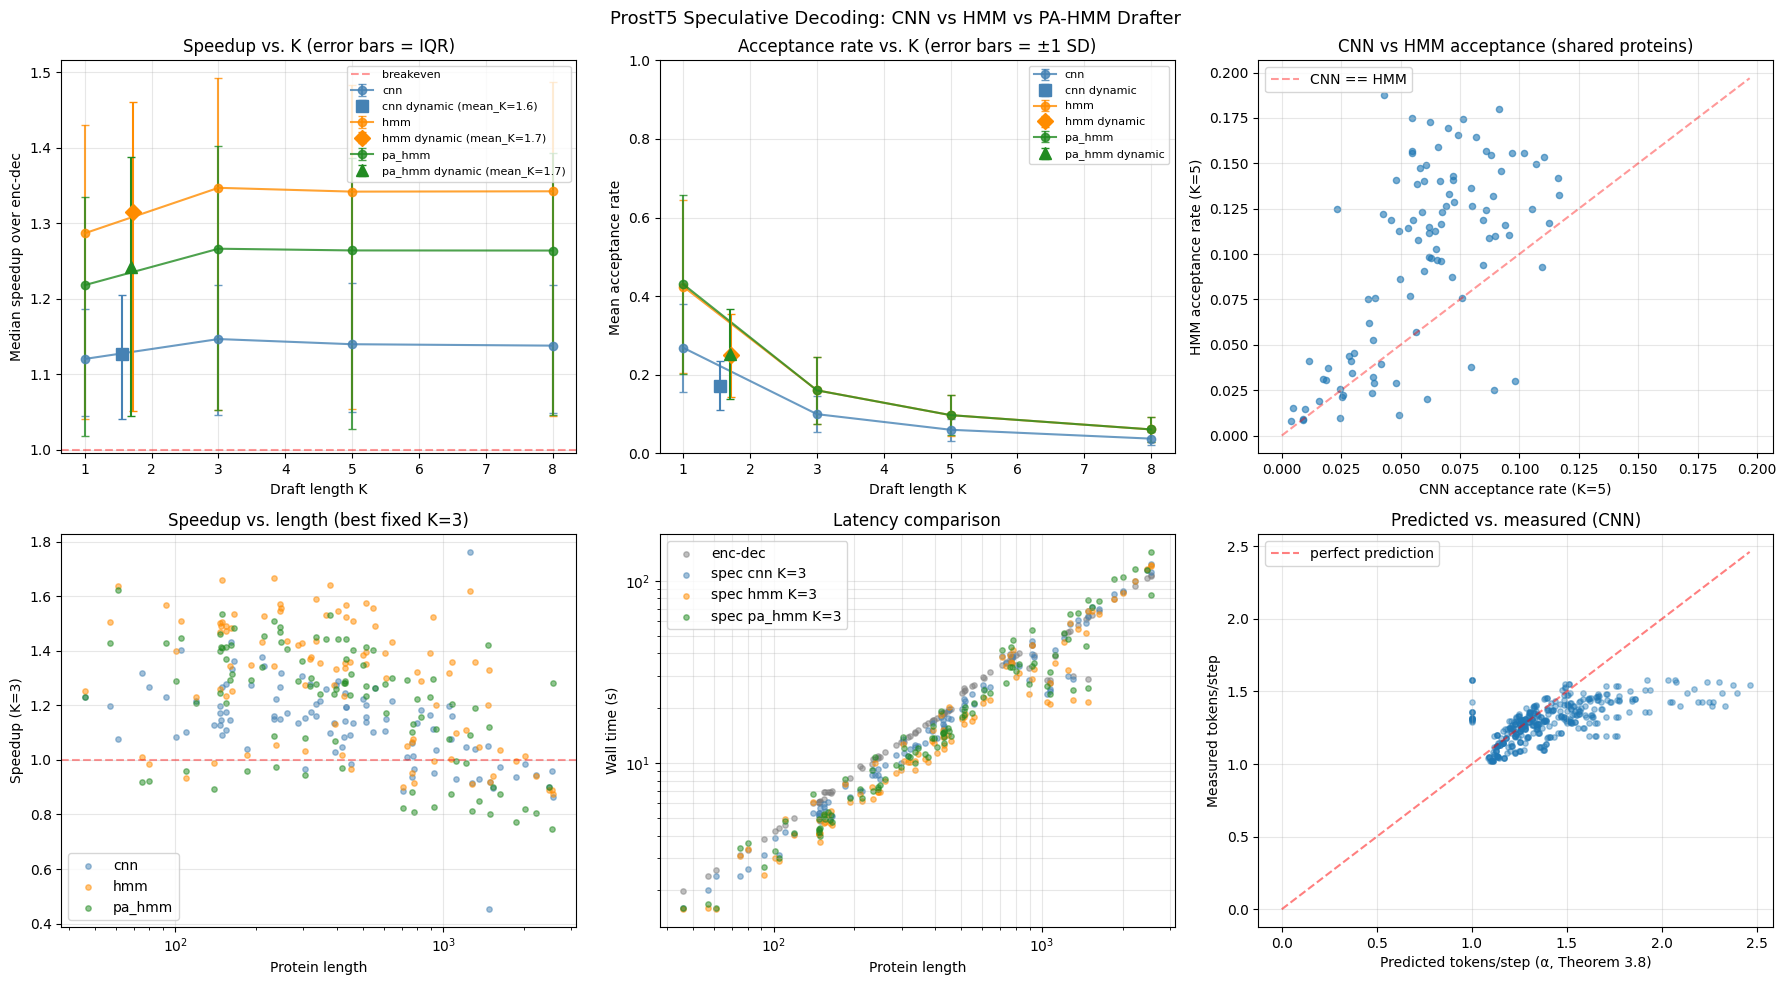

Saved to /kaggle/working/spec_decode_results/spec_decode_plots.png


In [24]:
#@title Plots: CNN vs HMM drafter comparison. { display-mode: "form" }
import matplotlib.pyplot as plt

COLORS = {"cnn": "steelblue", "hmm": "darkorange", "pa_hmm": "forestgreen"}
MARKERS_DYN = {"cnn": "s", "hmm": "D", "pa_hmm": "^"}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (0,0) Speedup vs K — CNN vs HMM, fixed + dynamic
ax = axes[0, 0]
for drafter in ["cnn", "hmm", "pa_hmm"]:
    sub = fixed_df[fixed_df["drafter"] == drafter]
    by_k = sub.groupby("K")["speedup"].median()
    by_k_q1 = sub.groupby("K")["speedup"].quantile(0.25)
    by_k_q3 = sub.groupby("K")["speedup"].quantile(0.75)
    ax.errorbar(by_k.index, by_k.values,
                yerr=[by_k.values - by_k_q1.values, by_k_q3.values - by_k.values],
                fmt="o-", label=drafter, color=COLORS[drafter], capsize=3, alpha=0.8)
    # Dynamic K point plotted at x = mean_K for that drafter
    dyn_sub = dyn_df[dyn_df["drafter"] == drafter]
    if len(dyn_sub) > 0:
        dyn_mean_k = dyn_sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")).mean()
        dyn_speedup_vals = dyn_sub["speedup"]
        dyn_speedup_med = dyn_speedup_vals.median()
        dyn_q1 = dyn_speedup_vals.quantile(0.25)
        dyn_q3 = dyn_speedup_vals.quantile(0.75)
        ax.errorbar([dyn_mean_k], [dyn_speedup_med],
                    yerr=[[dyn_speedup_med - dyn_q1], [dyn_q3 - dyn_speedup_med]],
                    fmt=MARKERS_DYN[drafter], color=COLORS[drafter], capsize=3,
                    markersize=8, zorder=5,
                    label=f"{drafter} dynamic (mean_K={dyn_mean_k:.1f})")
ax.axhline(1.0, color="red", linestyle="--", alpha=0.4, label="breakeven")
ax.set_xlabel("Draft length K")
ax.set_ylabel("Median speedup over enc-dec")
ax.set_title("Speedup vs. K (error bars = IQR)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (0,1) Acceptance rate vs K — CNN vs HMM, fixed + dynamic
ax = axes[0, 1]
for drafter in ["cnn", "hmm", "pa_hmm"]:
    sub = fixed_df[fixed_df["drafter"] == drafter]
    by_k = sub.groupby("K")["acceptance_rate"].mean()
    by_k_std = sub.groupby("K")["acceptance_rate"].std().fillna(0)
    ax.errorbar(by_k.index, by_k.values, yerr=by_k_std.values,
                fmt="o-", label=drafter, color=COLORS[drafter], capsize=3, alpha=0.8)
    dyn_sub = dyn_df[dyn_df["drafter"] == drafter]
    if len(dyn_sub) > 0:
        dyn_mean_k = dyn_sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")).mean()
        dyn_acc_mean = dyn_sub["acceptance_rate"].mean()
        dyn_acc_std = dyn_sub["acceptance_rate"].std()
        ax.errorbar([dyn_mean_k], [dyn_acc_mean],
                    yerr=[[dyn_acc_std]], fmt=MARKERS_DYN[drafter],
                    color=COLORS[drafter], capsize=3, markersize=8, zorder=5,
                    label=f"{drafter} dynamic")
ax.set_xlabel("Draft length K")
ax.set_ylabel("Mean acceptance rate")
ax.set_title("Acceptance rate vs. K (error bars = \u00b11 SD)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (0,2) CNN vs HMM acceptance rate scatter (shared proteins, K=5)
ax = axes[0, 2]
K_compare = 5
cnn_k5 = fixed_df[(fixed_df["drafter"] == "cnn") & (fixed_df["K"] == K_compare)].set_index("protein_id")
hmm_k5 = fixed_df[(fixed_df["drafter"] == "hmm") & (fixed_df["K"] == K_compare)].set_index("protein_id")
shared = cnn_k5.index.intersection(hmm_k5.index)
if len(shared) > 0:
    ax.scatter(cnn_k5.loc[shared, "acceptance_rate"], hmm_k5.loc[shared, "acceptance_rate"],
               alpha=0.6, s=20)
    lim = max(cnn_k5.loc[shared, "acceptance_rate"].max(),
              hmm_k5.loc[shared, "acceptance_rate"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", alpha=0.4, label="CNN == HMM")
    ax.set_xlabel(f"CNN acceptance rate (K={K_compare})")
    ax.set_ylabel(f"HMM acceptance rate (K={K_compare})")
    ax.set_title("CNN vs HMM acceptance (shared proteins)")
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No shared proteins yet", ha="center", va="center", transform=ax.transAxes)

# (1,0) Speedup vs length — best fixed K, both drafters
ax = axes[1, 0]
best_k = fixed_df.groupby("K")["speedup"].median().idxmax() if len(fixed_df) > 0 else 5
for drafter in ["cnn", "hmm", "pa_hmm"]:
    sub = fixed_df[(fixed_df["drafter"] == drafter) & (fixed_df["K"] == best_k)]
    ax.scatter(sub["length"], sub["speedup"], alpha=0.5, s=15,
               label=drafter, color=COLORS[drafter])
ax.axhline(1.0, color="red", linestyle="--", alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("Protein length")
ax.set_ylabel(f"Speedup (K={best_k})")
ax.set_title(f"Speedup vs. length (best fixed K={best_k})")
ax.legend()
ax.grid(True, alpha=0.3)

# (1,1) Latency: enc-dec vs CNN vs HMM (best fixed K)
ax = axes[1, 1]
ax.scatter(encdec_df["length"], encdec_df["wall_s"], alpha=0.5, s=15,
           label="enc-dec", color="gray")
for drafter in ["cnn", "hmm", "pa_hmm"]:
    sub = fixed_df[(fixed_df["drafter"] == drafter) & (fixed_df["K"] == best_k)]
    ax.scatter(sub["length"], sub["wall_s"], alpha=0.5, s=15,
               label=f"spec {drafter} K={best_k}", color=COLORS[drafter])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Protein length")
ax.set_ylabel("Wall time (s)")
ax.set_title("Latency comparison")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# (1,2) Predicted vs measured (CNN only, needs alpha from notebook 1)
ax = axes[1, 2]
if len(comp_df) > 0:
    ax.scatter(comp_df["predicted_tok_per_step"], comp_df["measured_tok_per_step"],
               alpha=0.4, s=15)
    max_val = max(comp_df["predicted_tok_per_step"].max(), comp_df["measured_tok_per_step"].max())
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="perfect prediction")
    ax.set_xlabel("Predicted tokens/step (\u03b1, Theorem 3.8)")
    ax.set_ylabel("Measured tokens/step")
    ax.set_title("Predicted vs. measured (CNN)")
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "Run baseline notebook first\nfor \u03b1 predictions",
            ha="center", va="center", transform=ax.transAxes)

fig.suptitle("ProstT5 Speculative Decoding: CNN vs HMM vs PA-HMM Drafter", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "spec_decode_plots.png", dpi=150)
plt.show()
print(f"Saved to {RESULTS_DIR / 'spec_decode_plots.png'}")


In [25]:
#@title Overhead analysis — draft runtime + vRAM per drafter. { display-mode: "form" }

print("=== Draft Model Overhead Analysis ===\n")

# ── Parameter / memory footprint ──────────────────────────────────────────────
n_cnn     = sum(p.numel() for p in cnn.parameters())
n_prostt5 = sum(p.numel() for p in model.parameters())
print(f"enc-CNN params : {n_cnn:,}")
print(f"ProstT5 params : {n_prostt5:,}  (~{n_prostt5 / max(n_cnn,1):.0f}x larger)")
print("Profile HMM    : non-parametric, built per-protein from its MSA (CPU/numpy)\n")

DRAFT_K = 5   # block size used for the simulated decode (matches K_init)


def _aa_to_token_ids(aa_seq: str) -> list:
    """Map an AA string to ProstT5 decoder token IDs (skips non-standard residues)."""
    ids = []
    for c in aa_seq:
        j = AA_LETTERS.find(c)
        if j >= 0:
            ids.append(CNN_IDX_TO_TOKEN_ID[j])
    return ids


def _encdec_wall(uid: str, rec: dict) -> float:
    """Reuse the measured enc-dec wall time from the benchmark if available."""
    if "results" in globals():
        for r in results:
            if r["protein_id"] == uid and r["drafter"] == "enc_dec":
                return r["wall_s"]
    return time_encdec(rec["3di"])


def _measure_cnn_draft(rec: dict) -> float:
    """
    Total CNN draft time for the whole protein. The enc-CNN is prefix-independent,
    so it drafts all L positions in a single forward pass (called once per decode).
    """
    enc_input = tokenizer([_format_3di(rec["3di"])], add_special_tokens=True,
                          return_tensors="pt").to(device)
    _sync(); t0 = time.perf_counter()
    with torch.inference_mode():
        h = encoder(input_ids=enc_input.input_ids,
                    attention_mask=enc_input.attention_mask).last_hidden_state
        _ = cnn(h[:, 1:-1, :].float())
    _sync()
    return time.perf_counter() - t0


def _measure_iterative_draft(drafter_obj, rec: dict, K: int = DRAFT_K):
    """
    Total time spent in get_draft_logits over a simulated full-length decode at
    block size K (assuming 100% acceptance → one draft call per block of K).
    This mirrors exactly how the drafter is queried inside speculative_decode_greedy
    and exposes the real per-decode overhead (for PA-HMM, the forward algorithm).
    Returns (total_seconds, n_calls).
    """
    acc = _aa_to_token_ids(rec["aa"])
    n = len(acc)
    if n == 0:
        return float("nan"), 0
    # warmup (one full draft call to stabilise allocation/JIT)
    _ = drafter_obj.get_draft_logits(0, acc, None)
    _sync(); t0 = time.perf_counter()
    pos, n_calls = 0, 0
    while pos < n:
        _ = drafter_obj.get_draft_logits(pos, acc, None)
        n_calls += 1
        pos += K
    _sync()
    return time.perf_counter() - t0, n_calls


# ── Per-protein draft runtime across a length range ───────────────────────────
sp = sorted(test_set.items(), key=lambda kv: kv[1]["length"])
if len(sp) >= 4:
    idxs = sorted({0, len(sp) // 3, 2 * len(sp) // 3, len(sp) - 1})
else:
    idxs = list(range(len(sp)))
sample = [sp[i] for i in idxs]

print(f"--- Total draft time per decode (block K={DRAFT_K}, 100% acceptance) ---")
header = (f"{'protein':<10} {'L':>4} {'enc-dec(s)':>11} | "
          f"{'CNN(ms)':>9} {'HMM(ms)':>9} {'PA-HMM(ms)':>11} | "
          f"{'PA/encdec':>9} {'PA ms/call':>11}")
print(header)
print("-" * len(header))

for uid, rec in sample:
    if not rec.get("aa"):
        continue
    L = rec["length"]
    t_enc = _encdec_wall(uid, rec)

    cnn_ms = _measure_cnn_draft(rec) * 1e3

    hmm_d = hmm_drafters.get(uid) if "hmm_drafters" in globals() else None
    if hmm_d is not None:
        hmm_s, _ = _measure_iterative_draft(hmm_d, rec)
        hmm_ms = hmm_s * 1e3
    else:
        hmm_ms = float("nan")

    pa_d = pa_hmm_drafters.get(uid) if "pa_hmm_drafters" in globals() else None
    if pa_d is not None:
        pa_s, pa_calls = _measure_iterative_draft(pa_d, rec)
        pa_ms = pa_s * 1e3
        pa_pct = (pa_s / t_enc * 100) if t_enc and t_enc > 0 else float("nan")
        pa_per_call = pa_ms / pa_calls if pa_calls else float("nan")
    else:
        pa_ms = pa_pct = pa_per_call = float("nan")

    print(f"{uid:<10} {L:>4} {t_enc:>11.3f} | "
          f"{cnn_ms:>9.2f} {hmm_ms:>9.2f} {pa_ms:>11.2f} | "
          f"{pa_pct:>8.1f}% {pa_per_call:>11.3f}")

print("\nInterpretation:")
print("  • CNN     : single prefix-independent forward → constant, sub-ms overhead.")
print("  • HMM     : static Viterbi logits precomputed once → get_draft_logits is a")
print("              cheap array slice (negligible per-call cost).")
print("  • PA-HMM  : prefix-aware forward algorithm re-runs each draft call, so its")
print("              overhead grows with length — the price of 'sharpening' on the")
print("              accepted prefix. Compare PA/enc-dec to judge if it pays off.")

# ── vRAM overhead note ────────────────────────────────────────────────────────
print("\n--- vRAM overhead ---")
print("HMM / PA-HMM drafters run on CPU (numpy) → no extra GPU vRAM beyond the")
print("shared encoder. Per-run peak vRAM is reported in the 'Aggregate results'")
print("cell (Peak vRAM by drafter table).")
if device.type == "cuda":
    _reset_peak_mem()
    uid, rec = sp[-1]                       # longest protein
    _ = speculative_decode_greedy(rec["3di"], K=5)
    print(f"Peak vRAM during spec decode (longest protein L={rec['length']}, "
          f"K=5): {_peak_mem_gb():.2f} GB")


=== Draft Model Overhead Analysis ===

enc-CNN params : 233,908
ProstT5 params : 2,818,852,864  (~12051x larger)
Profile HMM    : non-parametric, built per-protein from its MSA (CPU/numpy)

--- Total draft time per decode (block K=5, 100% acceptance) ---
protein       L  enc-dec(s) |   CNN(ms)   HMM(ms)  PA-HMM(ms) | PA/encdec  PA ms/call
-------------------------------------------------------------------------------------
P01542       46       1.973 |     33.30      0.04       79.28 |      4.0%       7.928
P15378      248      10.788 |     65.79      0.14     7333.86 |     68.0%     146.677
P02768      609      29.411 |    268.05      0.31   103794.20 |    352.9%     850.772
P13368     2554     106.551 |   2348.75      1.31  6005095.09 |   5635.9%   11751.654

Interpretation:
  • CNN     : single prefix-independent forward → constant, sub-ms overhead.
  • HMM     : static Viterbi logits precomputed once → get_draft_logits is a
              cheap array slice (negligible per-call cost)

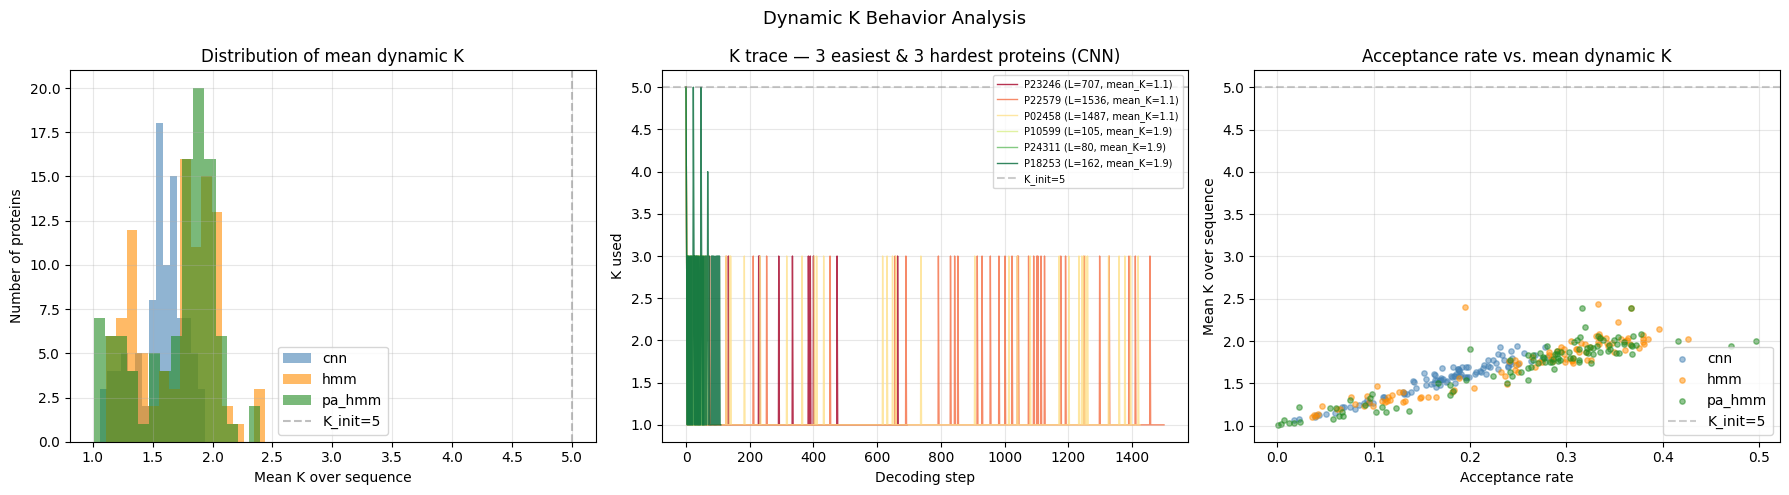

Saved to /kaggle/working/spec_decode_results/dynamic_k_analysis.png

=== Dynamic K summary ===

CNN:
  Mean K (across proteins): 1.55  (K_init=5, range [1.1, 1.9])
  Speedup: mean=1.13x  median=1.13x
  Acceptance rate: 0.172

HMM:
  Mean K (across proteins): 1.71  (K_init=5, range [1.1, 2.4])
  Speedup: mean=1.26x  median=1.32x
  Acceptance rate: 0.250

PA_HMM:
  Mean K (across proteins): 1.70  (K_init=5, range [1.0, 2.4])
  Speedup: mean=1.20x  median=1.24x
  Acceptance rate: 0.252


In [26]:
#@title Dynamic K behavior analysis. { display-mode: "form" }

if len(dyn_df) == 0:
    print("No dynamic K results yet.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (0) Distribution of mean_K across proteins, per drafter
    ax = axes[0]
    for drafter in ["cnn", "hmm", "pa_hmm"]:
        sub = dyn_df[dyn_df["drafter"] == drafter]
        if len(sub) == 0:
            continue
        mean_ks = sub["k_history"].apply(
            lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")
        ).dropna()
        ax.hist(mean_ks, bins=15, alpha=0.6, label=drafter, color=COLORS[drafter])
    ax.axvline(5, color="gray", linestyle="--", alpha=0.5, label="K_init=5")
    ax.set_xlabel("Mean K over sequence")
    ax.set_ylabel("Number of proteins")
    ax.set_title("Distribution of mean dynamic K")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (1) K trace for 6 representative proteins (3 high-α, 3 low-α), CNN drafter
    ax = axes[1]
    cnn_dyn = dyn_df[dyn_df["drafter"] == "cnn"].copy()
    cnn_dyn["mean_k"] = cnn_dyn["k_history"].apply(
        lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")
    )
    cnn_dyn_sorted = cnn_dyn.dropna(subset=["mean_k"]).sort_values("mean_k")
    # Pick 3 lowest and 3 highest mean_K proteins
    representatives = pd.concat([cnn_dyn_sorted.head(3), cnn_dyn_sorted.tail(3)])
    cmap = plt.cm.RdYlGn
    for i, (_, row) in enumerate(representatives.iterrows()):
        hist = row["k_history"]
        if not isinstance(hist, list) or len(hist) == 0:
            continue
        color = cmap(i / max(len(representatives) - 1, 1))
        label = f"{row['protein_id']} (L={row['length']}, mean_K={row['mean_k']:.1f})"
        ax.plot(hist, alpha=0.8, linewidth=1, color=color, label=label)
    ax.axhline(5, color="gray", linestyle="--", alpha=0.4, label="K_init=5")
    ax.set_xlabel("Decoding step")
    ax.set_ylabel("K used")
    ax.set_title("K trace — 3 easiest & 3 hardest proteins (CNN)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

    # (2) mean_K vs acceptance rate scatter — does high acceptance → high mean_K?
    ax = axes[2]
    for drafter in ["cnn", "hmm", "pa_hmm"]:
        sub = dyn_df[dyn_df["drafter"] == drafter].copy()
        if len(sub) == 0:
            continue
        sub["mean_k"] = sub["k_history"].apply(
            lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")
        )
        ax.scatter(sub["acceptance_rate"], sub["mean_k"],
                   alpha=0.5, s=15, label=drafter, color=COLORS[drafter])
    ax.axhline(5, color="gray", linestyle="--", alpha=0.4, label="K_init=5")
    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Mean K over sequence")
    ax.set_title("Acceptance rate vs. mean dynamic K")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.suptitle("Dynamic K Behavior Analysis", fontsize=13)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "dynamic_k_analysis.png", dpi=150)
    plt.show()
    print(f"Saved to {RESULTS_DIR / 'dynamic_k_analysis.png'}")

    # Summary stats
    print("\n=== Dynamic K summary ===")
    for drafter in ["cnn", "hmm", "pa_hmm"]:
        sub = dyn_df[dyn_df["drafter"] == drafter].copy()
        if len(sub) == 0:
            continue
        sub["mean_k"] = sub["k_history"].apply(
            lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")
        )
        print(f"\n{drafter.upper()}:")
        print(f"  Mean K (across proteins): {sub['mean_k'].mean():.2f}  "
              f"(K_init=5, range [{sub['mean_k'].min():.1f}, {sub['mean_k'].max():.1f}])")
        print(f"  Speedup: mean={sub['speedup'].mean():.2f}x  median={sub['speedup'].median():.2f}x")
        print(f"  Acceptance rate: {sub['acceptance_rate'].mean():.3f}")

In [27]:
#@title Save all results to Drive. { display-mode: "form" }

# Save final state
save_spec_checkpoint({"results": results, "completed": list(completed)})

# Copy key outputs to Drive for persistence
if USE_DRIVE:
    import shutil
    drive_results = Path(DRIVE_ROOT) / "spec_decode_results"
    drive_results.mkdir(exist_ok=True)
    for f in RESULTS_DIR.glob("*"):
        if f.is_file():
            shutil.copy(f, drive_results / f.name)
    print(f"Results copied to Drive: {drive_results}")
else:
    print(f"Results at: {RESULTS_DIR}")

print("\nDone! Key files:")
print(f"  - spec_decode_results.csv (all timings)")
print(f"  - predicted_vs_measured.csv (α comparison)")
print(f"  - spec_decode_plots.png")

Results copied to Drive: /kaggle/working/prostT5_benchmarks/spec_decode_results

Done! Key files:
  - spec_decode_results.csv (all timings)
  - predicted_vs_measured.csv (α comparison)
  - spec_decode_plots.png
